# Assignment 3 - E-commerce Comments / Customer Interest Discovery

## Intelligent System Development

### Dataset
**eBay Reviews** — `ebay_reviews.csv`

### Four models to compare
1. Logistic Regression
2. Linear SVM
3. Multinomial Naive Bayes
4. Deep Learning - NumPy from Scratch

The main system pipeline is:



```text
Comment
   ↓
Tokens
   ↓
Token IDs
   ↓
Vector / Embedding
```

The Deep Learning section follows the agreed nine-step sequence exactly:

```text
Step 1 - Implement Activation Functions
Step 2 - Initialize the Network
Step 3 - Forward Propagation
Step 4 - Cross-Entropy Loss
Step 5 - Backpropagation
Step 6 - Gradient Descent
Step 7 - Training Loop
Step 8 - Prediction
Step 9 - Evaluation
```

**Important restriction:** the neural network is implemented with **NumPy only**.
No TensorFlow, PyTorch, Keras, or other Deep Learning framework is used.

## 1. Learning Objectives

By the end of this notebook we should be able to:

1. Understand the structure, meaning, and limitations of the eBay reviews dataset.
2. Audit and clean missing values, duplicates, invalid values, and review text.
3. Define a concrete e-commerce customer-interest task from the available fields.
4. Convert natural language reviews into a mathematical representation for machine learning.
5. Perform feature engineering and feature selection so that the model uses informative
   features and avoids unnecessary dimensions.
6. Train three traditional machine-learning classifiers.
7. Build a text neural network from scratch using NumPy and a learnable embedding layer.
8. Evaluate and compare **all four models together on the same held-out test set**.
9. Persist the best ML model and the Deep Learning model for Web/Mobile inference.

## 2. Problem Definition - From Reviews to Product Interest

the e-commerce application may use customer comments/reviews
to discover interests such as the product category a customer is interested in.

For this dataset, one row represents one **product review**. The available attributes are:

- `category` - product category associated with the review
- `review title` - short review title
- `review content` - review text
- `rating` - numerical review rating from 1 to 5

We define the supervised task as:

```text
X = review title + review content + auxiliary rating signal
y = product-category interest
```

The raw `category` field contains a long tail with many categories that have only a few
observations. For a robust multi-class experiment and a from-scratch NumPy neural network,
we define the target as the **15 most frequent product categories plus one `Other` class**.

This is a task-definition choice, not a claim that the rare categories are unimportant.
The raw category distribution is still reported in the EDA section.

### Main question

> Can the review text, supported by the rating signal, predict the product category
> that represents the reviewer's product interest?

This makes the application a **multi-class text classification** problem.

### Dataset Source

The uploaded file is the raw `ebay_reviews.csv` dataset described on Kaggle as
an eBay review dataset with four columns: product category, review title, review content,
and rating.

Kaggle source:

https://www.kaggle.com/datasets/wojtekbonicki/ebay-reviews

The Kaggle page describes `ebay_reviews.csv` as the uncleaned version that should be
preprocessed before machine learning.

# 3. Imports and Reproducibility

The traditional ML part may use scikit-learn because the A3 requirement only forbids
external Deep Learning frameworks for the neural network.

The Deep Learning section itself uses:

- NumPy arrays
- matrix multiplication
- ReLU
- Softmax
- cross-entropy
- manual backpropagation
- gradient descent

No TensorFlow / PyTorch / Keras is imported or used.

In [1]:
import os
import re
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import joblib

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = Path("/mnt/data/ebay_reviews.csv") if Path("/mnt/data/ebay_reviews.csv").exists() else NOTEBOOK_DIR / "data/ebay_reviews.csv"

MODEL_DIR = NOTEBOOK_DIR / "model_comments"
FIG_DIR = MODEL_DIR / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("scikit-learn version:", __import__("sklearn").__version__)
print("Random seed:", SEED)
print("Data path:", DATA_PATH)

NumPy version: 2.4.6
Pandas version: 3.0.3
scikit-learn version: 1.9.0
Random seed: 42
Data path: C:\Users\ADMIN\Downloads\Intelligent System\asssignment 3\DATA\comments\data\ebay_reviews.csv


# 4. Locate and Load the Dataset

The raw CSV is loaded first and kept unchanged.


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find {DATA_PATH}. Place ebay_reviews.csv in the data folder "
        "or update DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH)

print("First 5 rows:")
display(df_raw.head())

print("\nShape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

First 5 rows:


,category,review title,review content,rating
0,Headsets,Wireless gaming headset,This gaming headset ticks all the boxes # look...,5
1,Headsets,"Good for those with a big head, low budget","Easy setup, rated for 6 hours battery but mine...",3
2,Headsets,MezumiWireless Gaming Headset,I originally bought this wireless headset for ...,5
3,Headsets,HW- S2 great headset.,"This is my 2nd Mezumi headset, It kills the fi...",5
4,Headsets,BEST HEADPHONES I'VE PURCHASED IN MY ENTIRE LIFE,This is probably the best headset I've purchas...,5



Shape: (44756, 4)

Column names:
['category', 'review title', 'review content', 'rating']

Data types:


,dtype
category,str
review title,str
review content,str
rating,int64


## 4.1 Initial Dataset Observations

The current uploaded dataset contains **44,756 observations and 4 attributes**.

One observation is one product review. The two text columns are the core inputs for
the Comments / Interest problem.

The raw table is already small enough to inspect directly, but the text representation
will create a much higher-dimensional feature space than the original CSV.

In [3]:
print("Rows:", len(df_raw))
print("Columns:", df_raw.shape[1])

observation_table = pd.DataFrame({
    "Column": df_raw.columns,
    "Data type": [str(df_raw[c].dtype) for c in df_raw.columns],
    "Missing": [int(df_raw[c].isna().sum()) for c in df_raw.columns],
    "Unique values": [int(df_raw[c].nunique(dropna=True)) for c in df_raw.columns],
})
display(observation_table)

print("\nExample observation:")
display(df_raw.iloc[[0]])

Rows: 44756
Columns: 4


,Column,Data type,Missing,Unique values
0,category,str,0,162
1,review title,str,2,31899
2,review content,str,0,42293
3,rating,int64,0,5



Example observation:


,category,review title,review content,rating
0,Headsets,Wireless gaming headset,This gaming headset ticks all the boxes # look...,5


# 5. Data Quality Audit

A professional cleaning workflow should answer these questions explicitly:

1. Are there missing values?
2. Are there exact duplicate rows?
3. Are ratings valid?
4. Are categories blank or malformed?
5. Are review title/content fields empty?
6. Does the text contain boilerplate that should not become model features?
7. Are there extreme text lengths that need monitoring?

Each issue is checked separately before the modeling table is created.

### 5.1 Missing Values

The original dataset contains two missing values in `review title` and no missing values
in `review content`, `category`, or `rating`.

**Decision:**
- `review title` is optional auxiliary text, so missing titles are filled with an empty string.
- `review content` is the essential text field. If it were missing, a non-empty title could
  be used as a fallback; rows with neither title nor content would be removed.
- `category` and `rating` are required for supervised training; invalid or missing targets
  cannot be imputed.

In [4]:
missing_summary = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df_raw) * 100
).round(3)

display(missing_summary)

print("Decision:")
print("- Missing review title -> fill with empty string.")
print("- Missing review content -> use title as fallback; drop only if both are empty.")
print("- Missing category/rating -> cannot create a valid supervised target.")

,missing_count,missing_percent
review title,2,0.004
category,0,0.000
review content,0,0.000
rating,0,0.000


Decision:
- Missing review title -> fill with empty string.
- Missing review content -> use title as fallback; drop only if both are empty.
- Missing category/rating -> cannot create a valid supervised target.


### 5.2 Duplicate Rows

Exact duplicate rows represent repeated complete observations.

**Decision:** remove exact duplicates before splitting the data, because otherwise the same
review could receive unintended extra weight in training.

Only exact row duplicates are removed. Similar but non-identical reviews are not removed.

In [5]:
duplicate_count = int(df_raw.duplicated().sum())
print("Exact duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("Action: exact duplicates will be removed.")
else:
    print("Action: no exact duplicate rows are present, so no duplicate removal is required.")

Exact duplicate rows: 0
Action: no exact duplicate rows are present, so no duplicate removal is required.


### 5.3 Rating and Category Validity

Ratings should be integer values from 1 to 5.

The category is the supervised target, so blank categories cannot define a valid class.

In [6]:
rating_numeric = pd.to_numeric(df_raw["rating"], errors="coerce")
invalid_rating_mask = rating_numeric.isna() | ~rating_numeric.isin([1, 2, 3, 4, 5])

blank_category_mask = (
    df_raw["category"].isna()
    | (df_raw["category"].astype(str).str.strip() == "")
)

print("Invalid rating rows:", int(invalid_rating_mask.sum()))
print("Blank category rows:", int(blank_category_mask.sum()))

print("\nObserved rating values:")
print(sorted(pd.Series(rating_numeric.dropna().unique()).tolist()))

Invalid rating rows: 0
Blank category rows: 0

Observed rating values:
[1, 2, 3, 4, 5]


### 5.4 Empty Text and Text Boilerplate

A title may legitimately be empty, but the combined review representation must contain
actual text. We therefore inspect the number of empty titles and contents.

The source data also contains the phrase `Read full review...` in some review contents.
This phrase is web-page boilerplate rather than customer language, so it is removed during
text normalization.

In [7]:
title_empty = df_raw["review title"].fillna("").astype(str).str.strip().eq("").sum()
content_empty = df_raw["review content"].fillna("").astype(str).str.strip().eq("").sum()

print("Empty review titles:", int(title_empty))
print("Empty review contents:", int(content_empty))

boilerplate_count = (
    df_raw["review content"].fillna("").astype(str)
    .str.contains(r"Read full review\.\.\.", case=False, regex=True)
    .sum()
)

print("Rows containing 'Read full review...':", int(boilerplate_count))

Empty review titles: 2
Empty review contents: 0
Rows containing 'Read full review...': 12436


### 5.5 Cleaning Summary

The cleaning policy used below is explicit:

1. Copy the raw data.
2. Drop exact duplicate rows.
3. Coerce `rating` to numeric and keep only values in 1–5.
4. Strip whitespace from `category`.
5. Fill missing `review title` with `""`.
6. Use the review title as a fallback only when review content is missing.
7. Drop rows where both text fields are empty.
8. Normalize text by lowercasing, removing the known `Read full review...` boilerplate,
   normalizing whitespace, and retaining word characters needed by the tokenizer.

No arbitrary statistical outlier deletion is performed on review length. Very long reviews
are legitimate observations; they are handled later by a maximum sequence length only in the
Deep Learning representation.

In [8]:
df = df_raw.copy()

# 1) Exact duplicate removal.
df = df.drop_duplicates().reset_index(drop=True)

# 2) Clean target and rating.
df["category"] = df["category"].fillna("").astype(str).str.strip()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Keep only valid ratings and non-empty category.
df = df[df["rating"].isin([1, 2, 3, 4, 5])].copy()
df = df[df["category"].ne("")].copy()

# 3) Missing title/content handling.
df["review title"] = df["review title"].fillna("").astype(str)
df["review content"] = df["review content"].fillna("").astype(str)

missing_content = df["review content"].str.strip().eq("")
fallback_mask = missing_content & df["review title"].str.strip().ne("")
df.loc[fallback_mask, "review content"] = df.loc[fallback_mask, "review title"]

# Drop rows with no usable text at all.
no_text_mask = (
    df["review title"].str.strip().eq("")
    & df["review content"].str.strip().eq("")
)
df = df.loc[~no_text_mask].copy()

# Keep rating as an integer auxiliary signal.
df["rating"] = df["rating"].astype(int)

print("Rows after cleaning:", len(df))
print("Rows removed:", len(df_raw) - len(df))
print("Missing values after cleaning:")
display(df[["category", "review title", "review content", "rating"]].isna().sum().to_frame("missing"))

Rows after cleaning: 44756
Rows removed: 0
Missing values after cleaning:


,missing
category,0
review title,0
review content,0
rating,0


In [9]:
def normalize_review_text(text):
    text = str(text).lower()
    text = re.sub(r"read full review\.\.\.", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["title_clean"] = df["review title"].map(normalize_review_text)
df["content_clean"] = df["review content"].map(normalize_review_text)

# Title + content are the main review representation.
df["review_text"] = (
    df["title_clean"].str.strip()
    + " [SEP] "
    + df["content_clean"].str.strip()
).str.strip()

print("Example cleaned review:")
display(
    df[["review title", "review content", "review_text"]].head(3)
)

print("\nRemaining empty combined texts:", int(df["review_text"].str.strip().eq("").sum()))

Example cleaned review:


,review title,review content,review_text
0,Wireless gaming headset,This gaming headset ticks all the boxes # look...,wireless gaming headset [SEP] this gaming head...
1,"Good for those with a big head, low budget","Easy setup, rated for 6 hours battery but mine...","good for those with a big head, low budget [SE..."
2,MezumiWireless Gaming Headset,I originally bought this wireless headset for ...,mezumiwireless gaming headset [SEP] i original...



Remaining empty combined texts: 0


# 6. Exploratory Data Analysis

Before choosing the representation, we inspect:

1. Target/category distribution
2. Rating distribution
3. Review length distribution
4. Title and content length
5. Category coverage and the long-tail problem
6. Relationship between ratings and the most common categories

The purpose is not to pick a model from the plots. The purpose is to understand the data
and justify preprocessing and feature-engineering decisions.

In [10]:
category_counts = df["category"].value_counts()

print("Number of unique raw categories:", len(category_counts))
print("Top 20 categories:")
display(category_counts.head(20).to_frame("count"))

Number of unique raw categories: 162
Top 20 categories:


,count
category,
Cell Phones & Smartphones,9861
Digital Cameras,4565
Video Games,3588
Headphones,3442
Cordless Drills,1736
Video Game Consoles,1672
Monitors,1563
Camcorders,1514
"Mice, Trackballs & Touchpads",1247


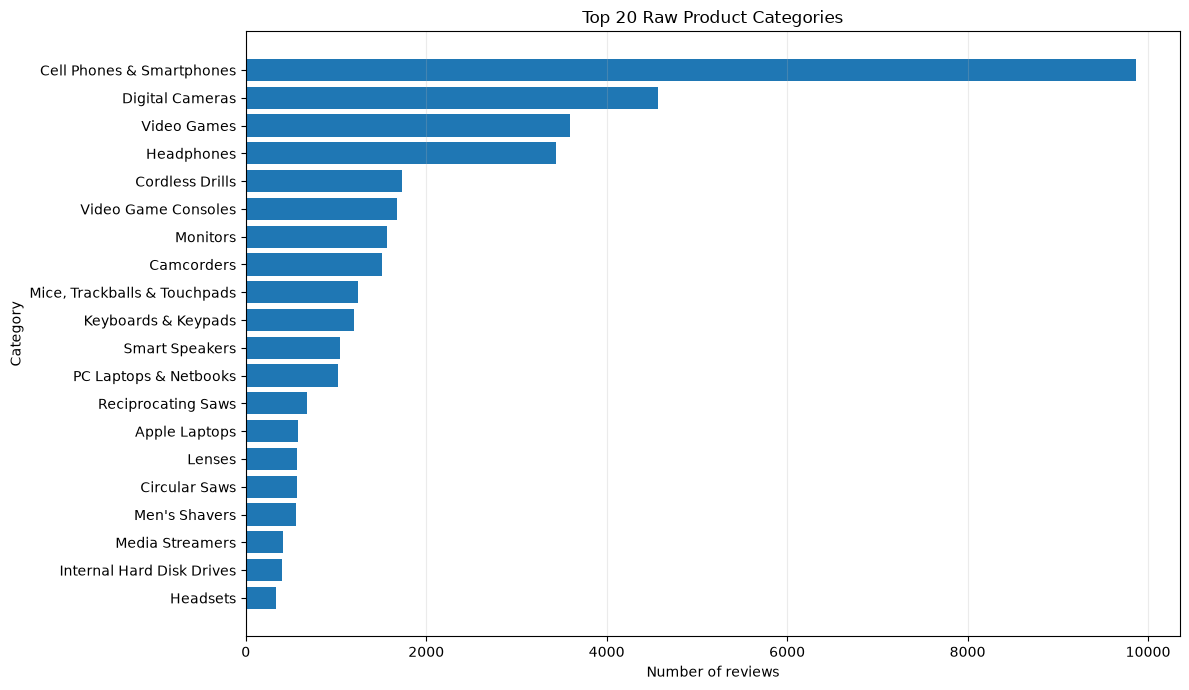

In [11]:
plt.figure(figsize=(12, 7))
top20 = category_counts.head(20).sort_values()
plt.barh(top20.index, top20.values)
plt.title("Top 20 Raw Product Categories")
plt.xlabel("Number of reviews")
plt.ylabel("Category")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_top20_categories.png", dpi=180)
plt.show()

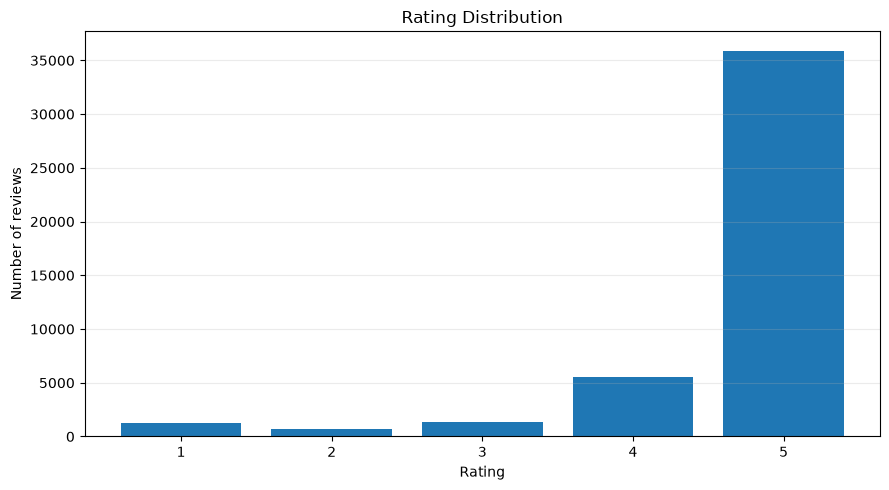

In [12]:
plt.figure(figsize=(9, 5))
rating_counts = df["rating"].value_counts().sort_index()
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_rating_distribution.png", dpi=180)
plt.show()

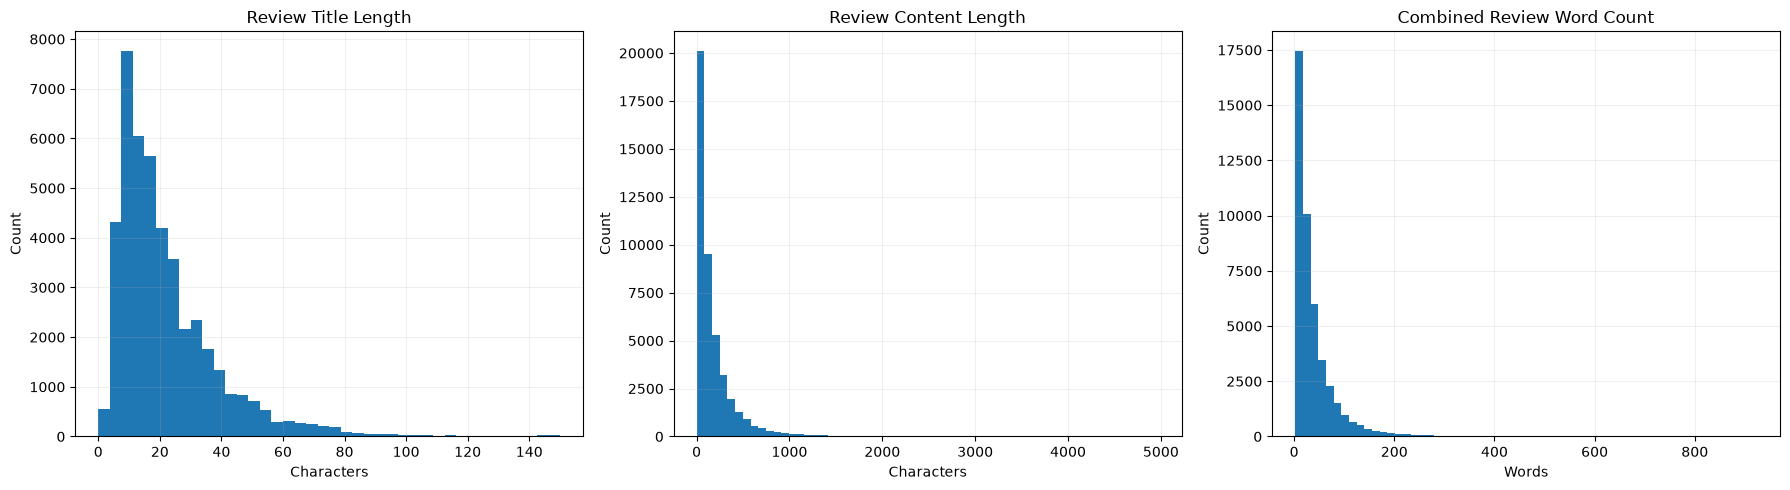

,title_char_len,content_char_len,review_word_count
count,44756.00,44756.00,44756.00
mean,22.23,186.67,40.28
std,17.28,270.36,52.43
min,0.00,1.00,2.00
50%,17.00,99.00,24.00
75%,28.00,224.00,49.00
90%,43.00,425.00,88.00
95%,55.00,618.00,126.00
99%,83.00,1287.00,254.00
max,150.00,4974.00,924.00


In [13]:
df["title_char_len"] = df["title_clean"].str.len()
df["content_char_len"] = df["content_clean"].str.len()
df["review_word_count"] = df["review_text"].str.findall(r"\b\w+\b").str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["title_char_len"], bins=40)
axes[0].set_title("Review Title Length")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(df["content_char_len"], bins=60)
axes[1].set_title("Review Content Length")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")

axes[2].hist(df["review_word_count"], bins=60)
axes[2].set_title("Combined Review Word Count")
axes[2].set_xlabel("Words")
axes[2].set_ylabel("Count")

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_text_length_distributions.png", dpi=180)
plt.show()

display(
    df[["title_char_len", "content_char_len", "review_word_count"]]
    .describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

,Cumulative coverage
Top 5,0.518
Top 10,0.679
Top 15,0.766
Top 20,0.817


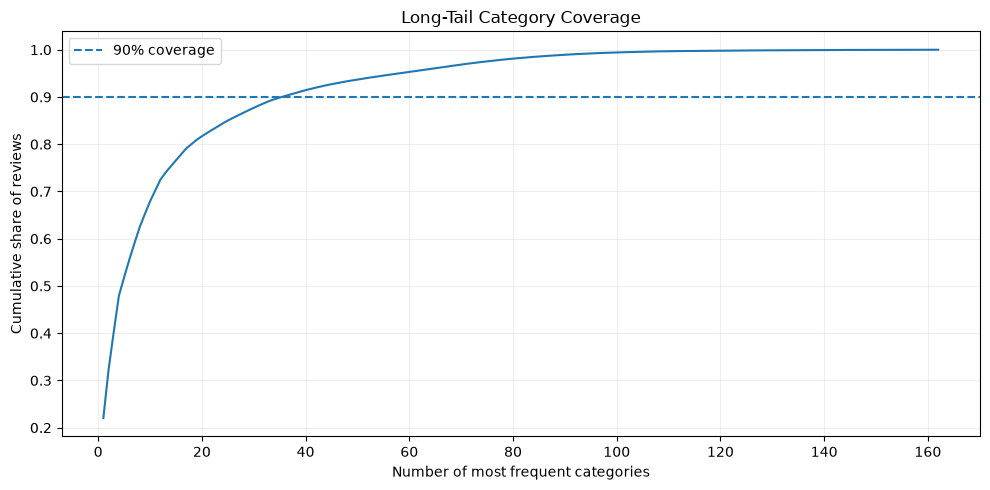

In [14]:
# Long-tail coverage: how much of the dataset is represented by the top categories?
cum_coverage = category_counts.cumsum() / len(df)

coverage_points = {
    "Top 5": float(cum_coverage.iloc[min(4, len(cum_coverage)-1)]),
    "Top 10": float(cum_coverage.iloc[min(9, len(cum_coverage)-1)]),
    "Top 15": float(cum_coverage.iloc[min(14, len(cum_coverage)-1)]),
    "Top 20": float(cum_coverage.iloc[min(19, len(cum_coverage)-1)]),
}

display(pd.DataFrame(
    {"Cumulative coverage": coverage_points}
).assign(**{"Cumulative coverage": lambda x: x["Cumulative coverage"].round(3)}))

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cum_coverage) + 1), cum_coverage.values)
plt.axhline(0.9, linestyle="--", label="90% coverage")
plt.xlabel("Number of most frequent categories")
plt.ylabel("Cumulative share of reviews")
plt.title("Long-Tail Category Coverage")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_category_coverage.png", dpi=180)
plt.show()

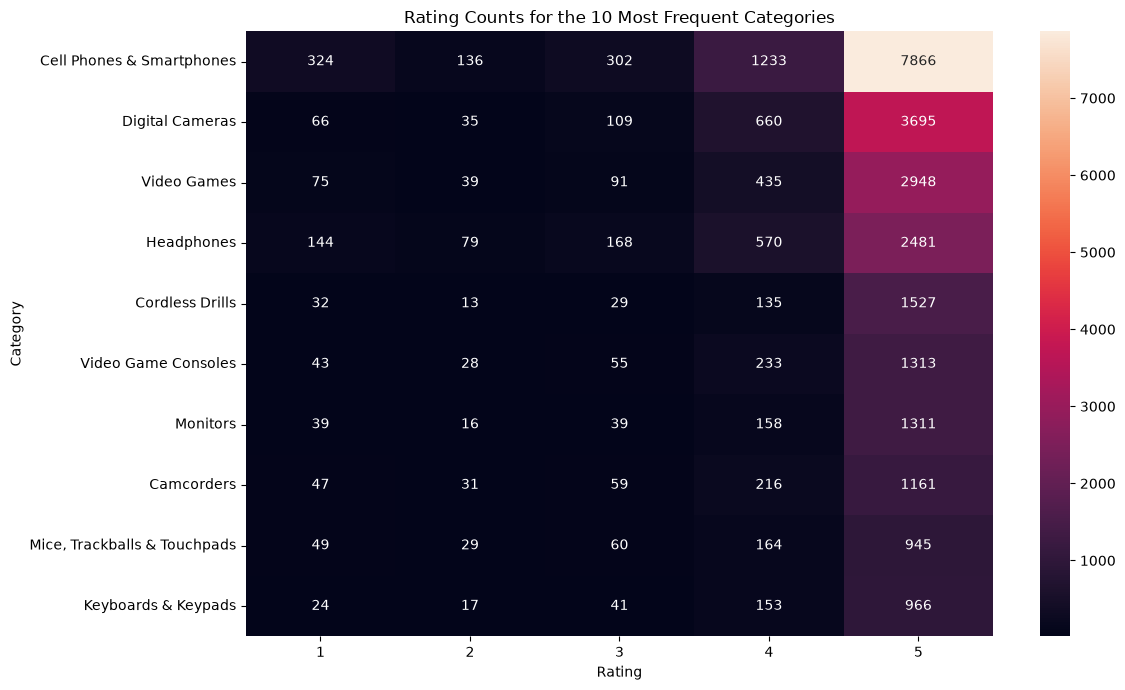

In [15]:
top10_categories = category_counts.head(10).index
rating_by_top_category = (
    df[df["category"].isin(top10_categories)]
    .groupby(["category", "rating"])
    .size()
    .unstack(fill_value=0)
    .reindex(top10_categories)
)

plt.figure(figsize=(12, 7))
sns.heatmap(rating_by_top_category, annot=True, fmt="d")
plt.title("Rating Counts for the 10 Most Frequent Categories")
plt.xlabel("Rating")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_rating_by_top_category.png", dpi=180)
plt.show()

# 7. Feature Engineering and Target Definition

Feature engineering is especially important for this dataset because the original CSV
contains only four columns, but not every field should be treated equally.

### Feature decisions

**Keep**
- `review title`: concise product/experience cues
- `review content`: main interest-bearing text
- `rating`: small auxiliary numerical signal

**Exclude**
- `category`: this is the target, so using it as an input would be direct target leakage
- any row index: it has no business meaning

### Text representation for traditional ML

```text
review title + review content
        ↓
TF-IDF word n-grams
        ↓
chi-square feature selection
        ↓
sparse numerical matrix
```

We use TF-IDF rather than feeding raw strings to the models. Feature selection is applied
after TF-IDF so that low-information terms are removed.

### Target engineering

The raw category space is highly long-tailed. We use the 15 most frequent raw categories as
explicit classes and map every remaining category to `Other`.

The resulting task is therefore a 16-class classification problem.

In [16]:
TOP_K = 15
TOP_CATEGORIES = category_counts.head(TOP_K).index.tolist()
OTHER_LABEL = "Other"

df["interest_category"] = np.where(
    df["category"].isin(TOP_CATEGORIES),
    df["category"],
    OTHER_LABEL,
)

CLASS_ORDER = TOP_CATEGORIES + [OTHER_LABEL]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_ORDER)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}

df["target_id"] = df["interest_category"].map(CLASS_TO_ID).astype(int)

print("Final task classes:")
for i, cls in enumerate(CLASS_ORDER):
    print(f"{i:2d} -> {cls}")

print("\nTarget distribution:")
target_counts = df["interest_category"].value_counts().reindex(CLASS_ORDER)
display(target_counts.to_frame("count").assign(percent=lambda x: (x["count"] / len(df) * 100).round(2)))

Final task classes:
 0 -> Cell Phones & Smartphones
 1 -> Digital Cameras
 2 -> Video Games
 3 -> Headphones
 4 -> Cordless Drills
 5 -> Video Game Consoles
 6 -> Monitors
 7 -> Camcorders
 8 -> Mice, Trackballs & Touchpads
 9 -> Keyboards & Keypads
10 -> Smart Speakers
11 -> PC Laptops & Netbooks
12 -> Reciprocating Saws
13 -> Apple Laptops
14 -> Lenses
15 -> Other

Target distribution:


,count,percent
interest_category,,
Cell Phones & Smartphones,9861,22.03
Digital Cameras,4565,10.20
Video Games,3588,8.02
Headphones,3442,7.69
Cordless Drills,1736,3.88
Video Game Consoles,1672,3.74
Monitors,1563,3.49
Camcorders,1514,3.38
"Mice, Trackballs & Touchpads",1247,2.79


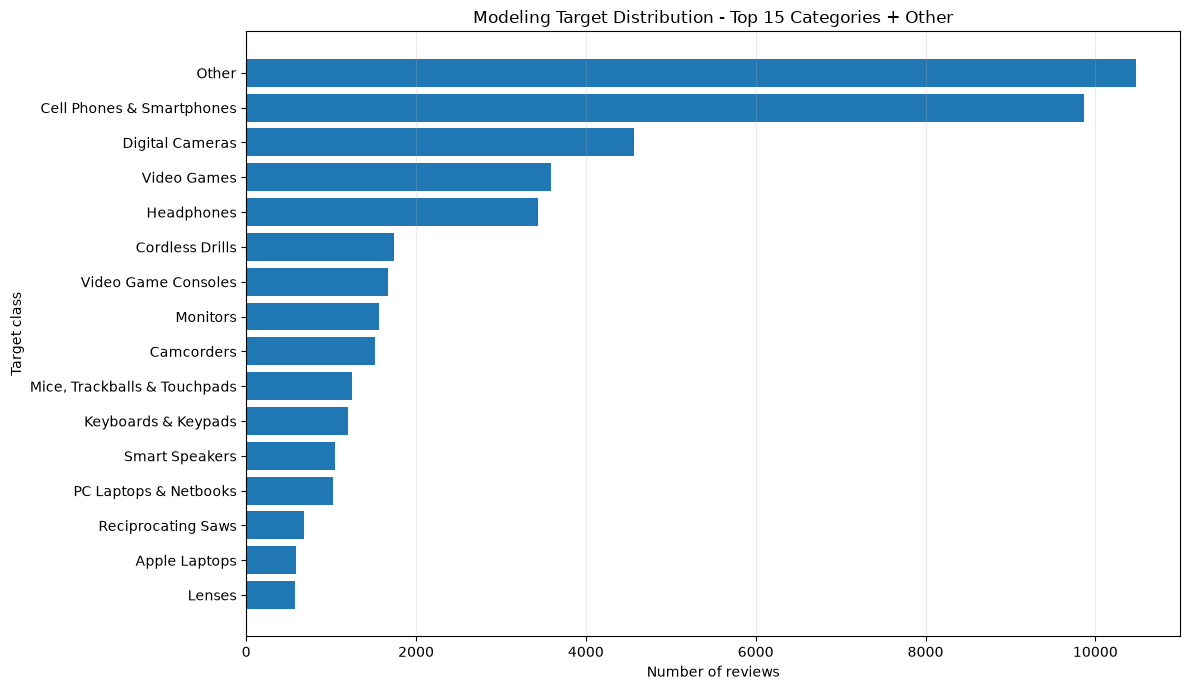

In [17]:
plt.figure(figsize=(12, 7))
target_plot = target_counts.sort_values()
plt.barh(target_plot.index, target_plot.values)
plt.title("Modeling Target Distribution - Top 15 Categories + Other")
plt.xlabel("Number of reviews")
plt.ylabel("Target class")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_modeling_target_distribution.png", dpi=180)
plt.show()

### Representation Requirement from A2

For this text dataset, one review is transformed through two parallel views.

**Traditional ML representation**

```text
Review text
   ↓
Tokens / n-grams
   ↓
TF-IDF
   ↓
Selected numerical feature vector
```

**Deep Learning representation**

```text
Review text
   ↓
Tokens
   ↓
Token IDs
   ↓
Learned Embedding Matrix
   ↓
Mean pooled text representation
   ↓
Dense hidden layers
```

The second representation is learned jointly with the classifier. This is the direct
adaptation of the A2 text representation principle to the Deep Learning model.

# 8. Train / Validation / Test Split

We use:

- **70% training**
- **15% validation**
- **15% test**

The split is stratified on the 16-class target so that each class remains represented.

The test set is kept untouched until the final comparison of all four models.

In [18]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["target_id"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["target_id"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

for name, subset in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{name} target distribution:")
    dist = subset["interest_category"].value_counts().reindex(CLASS_ORDER).fillna(0)
    print(dist.to_dict())

Train: (31329, 12)
Validation: (6713, 12)
Test: (6714, 12)

Train target distribution:
{'Cell Phones & Smartphones': 6903, 'Digital Cameras': 3195, 'Video Games': 2512, 'Headphones': 2409, 'Cordless Drills': 1215, 'Video Game Consoles': 1170, 'Monitors': 1094, 'Camcorders': 1060, 'Mice, Trackballs & Touchpads': 873, 'Keyboards & Keypads': 841, 'Smart Speakers': 729, 'PC Laptops & Netbooks': 713, 'Reciprocating Saws': 475, 'Apple Laptops': 408, 'Lenses': 401, 'Other': 7331}

Validation target distribution:
{'Cell Phones & Smartphones': 1479, 'Digital Cameras': 685, 'Video Games': 538, 'Headphones': 516, 'Cordless Drills': 260, 'Video Game Consoles': 251, 'Monitors': 234, 'Camcorders': 227, 'Mice, Trackballs & Touchpads': 187, 'Keyboards & Keypads': 180, 'Smart Speakers': 156, 'PC Laptops & Netbooks': 153, 'Reciprocating Saws': 102, 'Apple Laptops': 88, 'Lenses': 86, 'Other': 1571}

Test target distribution:
{'Cell Phones & Smartphones': 1479, 'Digital Cameras': 685, 'Video Games': 538, 

# 9. Leakage-Safe Preprocessing and Text Feature Selection

All feature-learning transformations are fitted on the **training set only**.

This is essential because fitting a vectorizer, scaler, vocabulary, or feature selector
using validation/test data would allow information from unseen data to influence the
representation.

### Traditional ML representation

1. Fit TF-IDF on `X_train`
2. Transform validation and test with the same vectorizer
3. Fit chi-square `SelectKBest` on training data only
4. Transform validation/test with the same selector
5. Fit a rating scaler on training ratings only
6. Append the scaled rating to the selected TF-IDF matrix

The resulting `X` matrices are sparse numerical representations.

In [19]:
X_train_text = train_df["review_text"].tolist()
X_val_text = val_df["review_text"].tolist()
X_test_text = test_df["review_text"].tolist()

y_train = train_df["target_id"].to_numpy(dtype=np.int64)
y_val = val_df["target_id"].to_numpy(dtype=np.int64)
y_test = test_df["target_id"].to_numpy(dtype=np.int64)

print("Training examples:", len(X_train_text))
print("Validation examples:", len(X_val_text))
print("Testing examples:", len(X_test_text))

Training examples: 31329
Validation examples: 6713
Testing examples: 6714


In [20]:
TFIDF_MAX_FEATURES = 30000
TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.98

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    max_features=TFIDF_MAX_FEATURES,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf = vectorizer.transform(X_val_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("TF-IDF feature count before selection:", X_train_tfidf.shape[1])
print("Train matrix shape:", X_train_tfidf.shape)
print("Validation matrix shape:", X_val_tfidf.shape)
print("Test matrix shape:", X_test_tfidf.shape)

TF-IDF feature count before selection: 30000
Train matrix shape: (31329, 30000)
Validation matrix shape: (6713, 30000)
Test matrix shape: (6714, 30000)


In [21]:
SELECTED_TFIDF_FEATURES = min(12000, X_train_tfidf.shape[1])

selector = SelectKBest(
    score_func=chi2,
    k=SELECTED_TFIDF_FEATURES,
)

X_train_text_sel = selector.fit_transform(X_train_tfidf, y_train)
X_val_text_sel = selector.transform(X_val_tfidf)
X_test_text_sel = selector.transform(X_test_tfidf)

selected_feature_names = np.asarray(vectorizer.get_feature_names_out())[selector.get_support()]

print("Selected TF-IDF features:", len(selected_feature_names))
print("Selected matrix shape:", X_train_text_sel.shape)

print("\nExamples of selected high-information terms:")
print(selected_feature_names[:80])

Selected TF-IDF features: 12000
Selected matrix shape: (31329, 12000)

Examples of selected high-information terms:
['00' '000' '000 shutter' '04' '0ah' '0ah battery' '10' '10 10'
 '10 aspect' '10 fps' '10 frames' '10 hours' '10 key' '10 laptop'
 '10 megapixel' '10 plus' '10 pro' '10 recommend' '10 sep' '10 years'
 '100 00' '100 recommend' '100 recommended' '1000' '1000xm2' '1000xm3'
 '100mm' '105' '105 lens' '105mm' '1080' '1080p' '1080p 60' '1080p 60fps'
 '10d' '10d sep' '10mp' '10x' '10x optical' '10x zoom' '11' '11 pro' '110'
 '110v' '12' '12 1mp' '12 inch' '12 megapixel' '12 megapixels' '12 mp'
 '12 volt' '12 years' '1200' '120hz' '128gb' '12gb' '12v' '12x' '13'
 '13 inch' '13 macbook' '135' '135mm' '14' '14 day' '14 megapixel' '144'
 '1440p' '144hz' '15' '15 inch' '15 macbook' '15 sep' '16' '16 10' '16 35'
 '16 50' '16 bit' '16 gb' '160']


In [22]:
# Rating is an auxiliary numeric feature. The scaler is fitted only on training data.
rating_scaler = StandardScaler()

rating_train = rating_scaler.fit_transform(
    train_df[["rating"]].to_numpy(dtype=np.float64)
)
rating_val = rating_scaler.transform(
    val_df[["rating"]].to_numpy(dtype=np.float64)
)
rating_test = rating_scaler.transform(
    test_df[["rating"]].to_numpy(dtype=np.float64)
)

# MultinomialNB needs non-negative features. To keep one common representation,
# use a [0, 1] min-max style mapping for the auxiliary rating instead of a negative z-score.
rating_minmax_train = (train_df["rating"].to_numpy(dtype=np.float64) - 1.0) / 4.0
rating_minmax_val = (val_df["rating"].to_numpy(dtype=np.float64) - 1.0) / 4.0
rating_minmax_test = (test_df["rating"].to_numpy(dtype=np.float64) - 1.0) / 4.0

X_train_ml = hstack(
    [X_train_text_sel, csr_matrix(rating_minmax_train.reshape(-1, 1))],
    format="csr",
)
X_val_ml = hstack(
    [X_val_text_sel, csr_matrix(rating_minmax_val.reshape(-1, 1))],
    format="csr",
)
X_test_ml = hstack(
    [X_test_text_sel, csr_matrix(rating_minmax_test.reshape(-1, 1))],
    format="csr",
)

print("Final ML input matrix:")
print("X_train:", X_train_ml.shape)
print("X_val  :", X_val_ml.shape)
print("X_test :", X_test_ml.shape)
print("Non-zero values in X_train:", X_train_ml.nnz)

Final ML input matrix:
X_train: (31329, 12001)
X_val  : (6713, 12001)
X_test : (6714, 12001)
Non-zero values in X_train: 574147


### Feature Selection Check

For text, "feature engineering" is not limited to inventing new columns.

It also means choosing **how language becomes features** and removing dimensions that are
unlikely to contribute enough signal.

The pipeline therefore performs:

```text
word / bigram candidate features
        ↓
TF-IDF weighting
        ↓
Chi-square relevance test
        ↓
20,000 selected text features
        +
1 compact rating feature
```

This gives the ML models a controlled representation instead of passing the entire raw
vocabulary to the classifier.

,feature,chi2_score
16818,mouse,3875.194735
14186,keyboard,3764.249740
16705,monitor,3555.785278
9913,game,3454.546752
14644,lens,3109.117097
7659,drill,2604.373947
3468,camera,2079.516789
18636,phone,1891.546109
15962,macbook,1881.442554
14692,lens sep,1823.025582


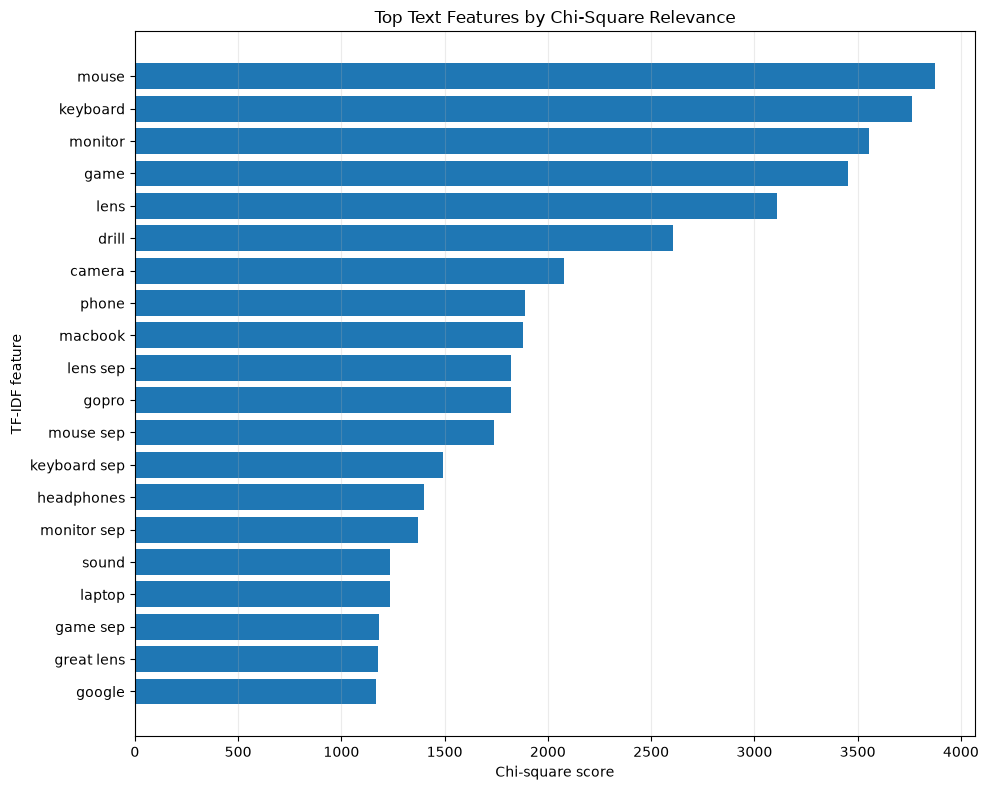

In [23]:
feature_score_df = pd.DataFrame({
    "feature": vectorizer.get_feature_names_out(),
    "chi2_score": selector.scores_,
}).dropna().sort_values("chi2_score", ascending=False)

display(feature_score_df.head(30))

plt.figure(figsize=(10, 8))
plot_df = feature_score_df.head(20).sort_values("chi2_score")
plt.barh(plot_df["feature"], plot_df["chi2_score"])
plt.title("Top Text Features by Chi-Square Relevance")
plt.xlabel("Chi-square score")
plt.ylabel("TF-IDF feature")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_top_text_features_chi2.png", dpi=180)
plt.show()

### Representation Example - One Review

A2 requires the representation to be visible, not hidden inside model code.

The next cell shows:

```text
Original review
      ↓
Normalized text
      ↓
Selected TF-IDF vector shape
```

For the Deep Learning path, a later cell will show:

```text
Tokens → Token IDs → Embedding tensor → pooled vector
```

In [24]:
example_idx = 0
print("Original title:")
print(train_df.iloc[example_idx]["review title"])
print("\nOriginal content:")
print(train_df.iloc[example_idx]["review content"])

print("\nNormalized review:")
print(train_df.iloc[example_idx]["review_text"])

print("\nTarget:")
print(train_df.iloc[example_idx]["interest_category"])

print("\nTraditional ML vector shape for one review:")
print(X_train_ml[example_idx].shape)

print("\nNumber of non-zero values in the vector:")
print(X_train_ml[example_idx].nnz)

Original title:
Looks great with good features.

Original content:
Phone appears to be okay after looking at phone carefully several cracks have be discovered on the back of phone and the front have a small air crack going straight down the side.

Normalized review:
looks great with good features. [SEP] phone appears to be okay after looking at phone carefully several cracks have be discovered on the back of phone and the front have a small air crack going straight down the side.

Target:
Cell Phones & Smartphones

Traditional ML vector shape for one review:
(1, 12001)

Number of non-zero values in the vector:
15


# 10. Model 1 - Logistic Regression

Logistic Regression is a strong linear baseline for high-dimensional TF-IDF text features.

It is useful here because:
- it works well with sparse text vectors;
- its coefficients can be inspected as feature evidence;
- it can output class probabilities for deployment.

The model uses the same leakage-safe `X_train_ml` representation as the other ML models.

In [25]:
ml_models = {}
ml_predictions = {}
ml_probabilities = {}
ml_training_times = {}
ml_results = []

start = time.time()

logreg = OneVsRestClassifier(
    LogisticRegression(
        C=4.0,
        max_iter=300,
        solver="liblinear",
        random_state=SEED,
    ),
    n_jobs=1,
)

logreg.fit(X_train_ml, y_train)
logreg_time = time.time() - start

logreg_pred = logreg.predict(X_test_ml)
logreg_prob = logreg.predict_proba(X_test_ml)

ml_models["Logistic Regression"] = logreg
ml_predictions["Logistic Regression"] = logreg_pred
ml_probabilities["Logistic Regression"] = logreg_prob
ml_training_times["Logistic Regression"] = logreg_time

print("Training time:", round(logreg_time, 2), "seconds")
print("Prediction shape:", logreg_pred.shape)
print("Probability shape:", logreg_prob.shape)

Training time: 5.31 seconds
Prediction shape: (6714,)
Probability shape: (6714, 16)


# 11. Model 2 - Linear SVM

Linear SVM is another strong text-classification baseline.

It usually handles sparse TF-IDF representations efficiently and directly optimizes a
large-margin decision boundary.

In [26]:
start = time.time()

svm_model = LinearSVC(
    C=1.5,
    random_state=SEED,
)

svm_model.fit(X_train_ml, y_train)
svm_time = time.time() - start

svm_pred = svm_model.predict(X_test_ml)
svm_scores = svm_model.decision_function(X_test_ml)

ml_models["Linear SVM"] = svm_model
ml_predictions["Linear SVM"] = svm_pred
ml_training_times["Linear SVM"] = svm_time

print("Training time:", round(svm_time, 2), "seconds")
print("Decision score shape:", svm_scores.shape)

Training time: 7.5 seconds
Decision score shape: (6714, 16)


# 12. Model 3 - Multinomial Naive Bayes

Multinomial Naive Bayes is a classic text-classification baseline.

It is computationally light and works naturally with non-negative TF-IDF-style features.
The shared ML representation therefore keeps all inputs non-negative.

In [27]:
start = time.time()

nb_model = MultinomialNB(alpha=0.25)

nb_model.fit(X_train_ml, y_train)
nb_time = time.time() - start

nb_pred = nb_model.predict(X_test_ml)
nb_prob = nb_model.predict_proba(X_test_ml)

ml_models["Multinomial Naive Bayes"] = nb_model
ml_predictions["Multinomial Naive Bayes"] = nb_pred
ml_probabilities["Multinomial Naive Bayes"] = nb_prob
ml_training_times["Multinomial Naive Bayes"] = nb_time

print("Training time:", round(nb_time, 2), "seconds")
print("Probability shape:", nb_prob.shape)

Training time: 0.04 seconds
Probability shape: (6714, 16)


# 13. Evaluate the Three Traditional ML Models

All three traditional models are evaluated on the same untouched test set.

For the multi-class task, the main comparison metrics are:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Balanced Accuracy
- One-vs-Rest ROC-AUC where a probability/score representation is available

Macro metrics are emphasized because the target is not perfectly balanced.

In [28]:
def softmax_numpy(scores):
    scores = np.asarray(scores, dtype=np.float64)
    shifted = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

# Convert Linear SVM decision scores to normalized class scores for ROC-AUC / display.
# These are NOT calibrated probabilities.
svm_pseudo_prob = softmax_numpy(svm_scores)

ml_probabilities["Linear SVM (normalized scores)"] = svm_pseudo_prob

def classification_metrics(y_true, y_pred, prob=None):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    if prob is not None:
        try:
            y_bin = label_binarize(y_true, classes=np.arange(len(CLASS_ORDER)))
            result["ROC_AUC_OVR_macro"] = roc_auc_score(
                y_bin,
                prob,
                multi_class="ovr",
                average="macro",
            )
        except ValueError:
            result["ROC_AUC_OVR_macro"] = np.nan
    else:
        result["ROC_AUC_OVR_macro"] = np.nan
    return result

ml_results = []

for name in ["Logistic Regression", "Linear SVM", "Multinomial Naive Bayes"]:
    pred = ml_predictions[name]
    prob = (
        ml_probabilities[name]
        if name in ml_probabilities
        else ml_probabilities["Linear SVM (normalized scores)"]
    )

    metrics = classification_metrics(y_test, pred, prob)
    metrics["Model"] = name
    metrics["Training_Time_sec"] = ml_training_times[name]
    ml_results.append(metrics)

traditional_results = pd.DataFrame(ml_results)[
    [
        "Model",
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "Balanced_Accuracy",
        "ROC_AUC_OVR_macro",
        "Training_Time_sec",
    ]
].sort_values("F1_macro", ascending=False).reset_index(drop=True)

display(traditional_results)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Balanced_Accuracy,ROC_AUC_OVR_macro,Training_Time_sec
0,Linear SVM,0.766607,0.799829,0.666386,0.720912,0.666386,0.950790,7.503092
1,Logistic Regression,0.764224,0.858607,0.640212,0.717623,0.640212,0.957979,5.313868
2,Multinomial Naive Bayes,0.714030,0.894670,0.501026,0.584423,0.501026,0.937572,0.036589


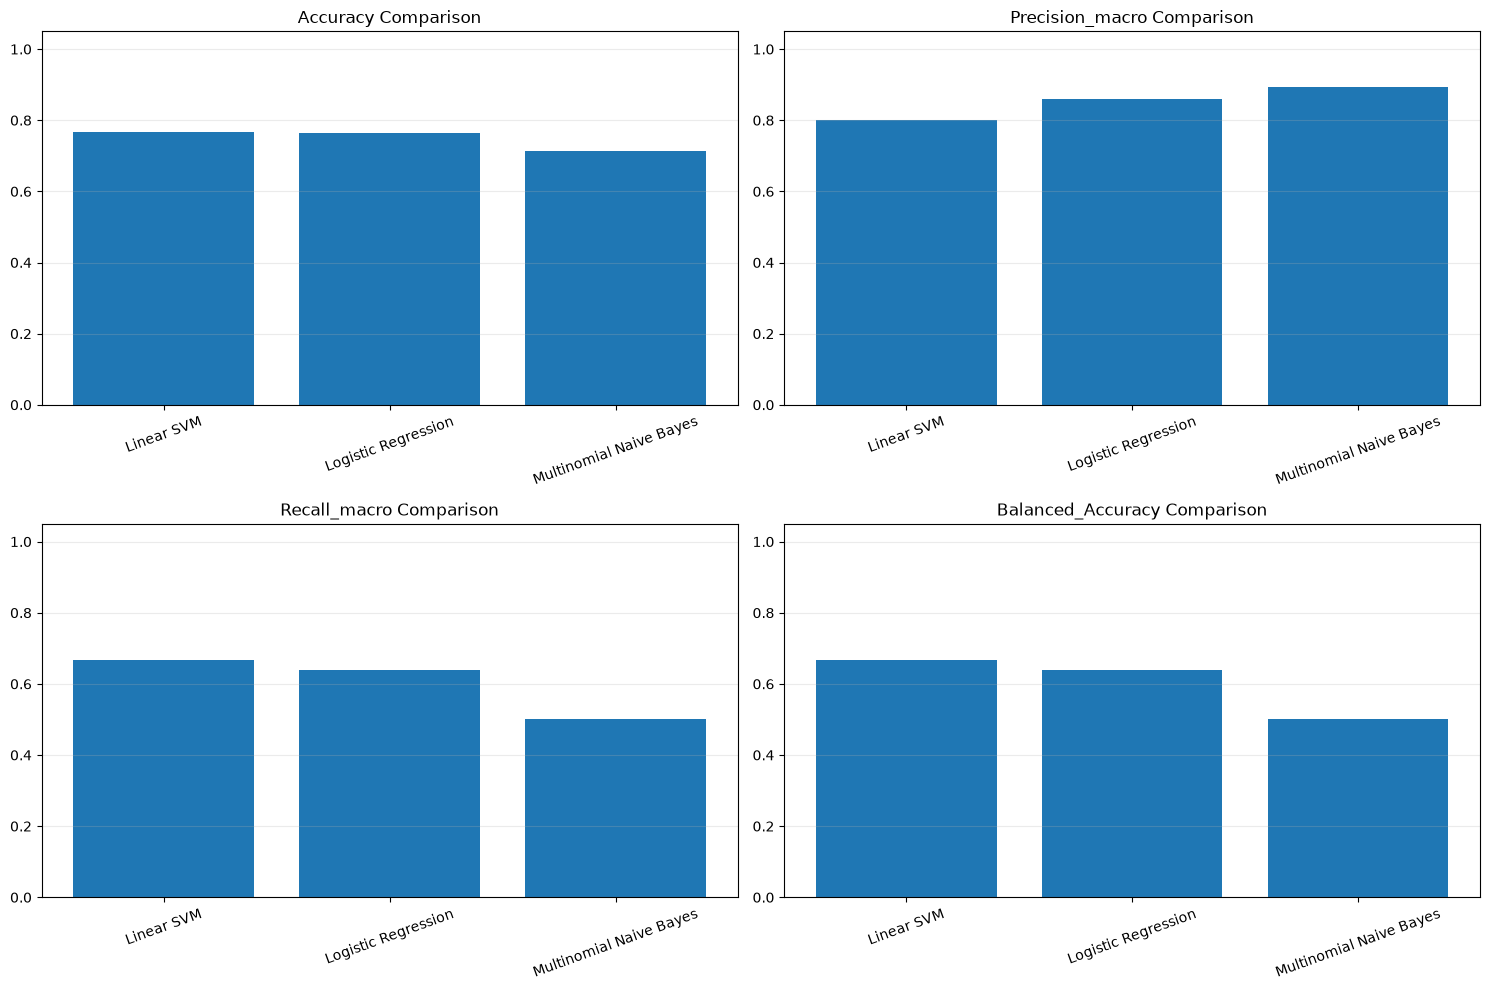

In [29]:
plot_metrics = [
    "Accuracy",
    "Precision_macro",
    "Recall_macro",
    "Balanced_Accuracy",
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for ax, metric in zip(axes, plot_metrics):
    axes_idx = list(axes).index(ax)
    vals = traditional_results[metric].to_numpy()
    ax.bar(traditional_results["Model"], vals)
    ax.set_title(f"{metric} Comparison")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / "08_traditional_ml_metric_comparison.png", dpi=180)
plt.show()

### Best ML Validation Rule

The notebook selects the strongest traditional ML model using **Macro F1** because:
- the target contains a majority class and an `Other` class;
- macro averaging gives every class equal metric weight;
- a model that predicts the majority classes well but ignores smaller classes should
  not automatically win.

The final four-model comparison will still show all metrics, so selection is transparent.

In [30]:
best_ml_name = traditional_results.iloc[0]["Model"]
print("Best traditional ML model by Macro F1:", best_ml_name)

Best traditional ML model by Macro F1: Linear SVM


### Detailed Test Evaluation - Best Traditional ML

A confusion matrix shows where category interests are confused with each other.

This is especially useful for text classification because related product categories
often use similar vocabulary.

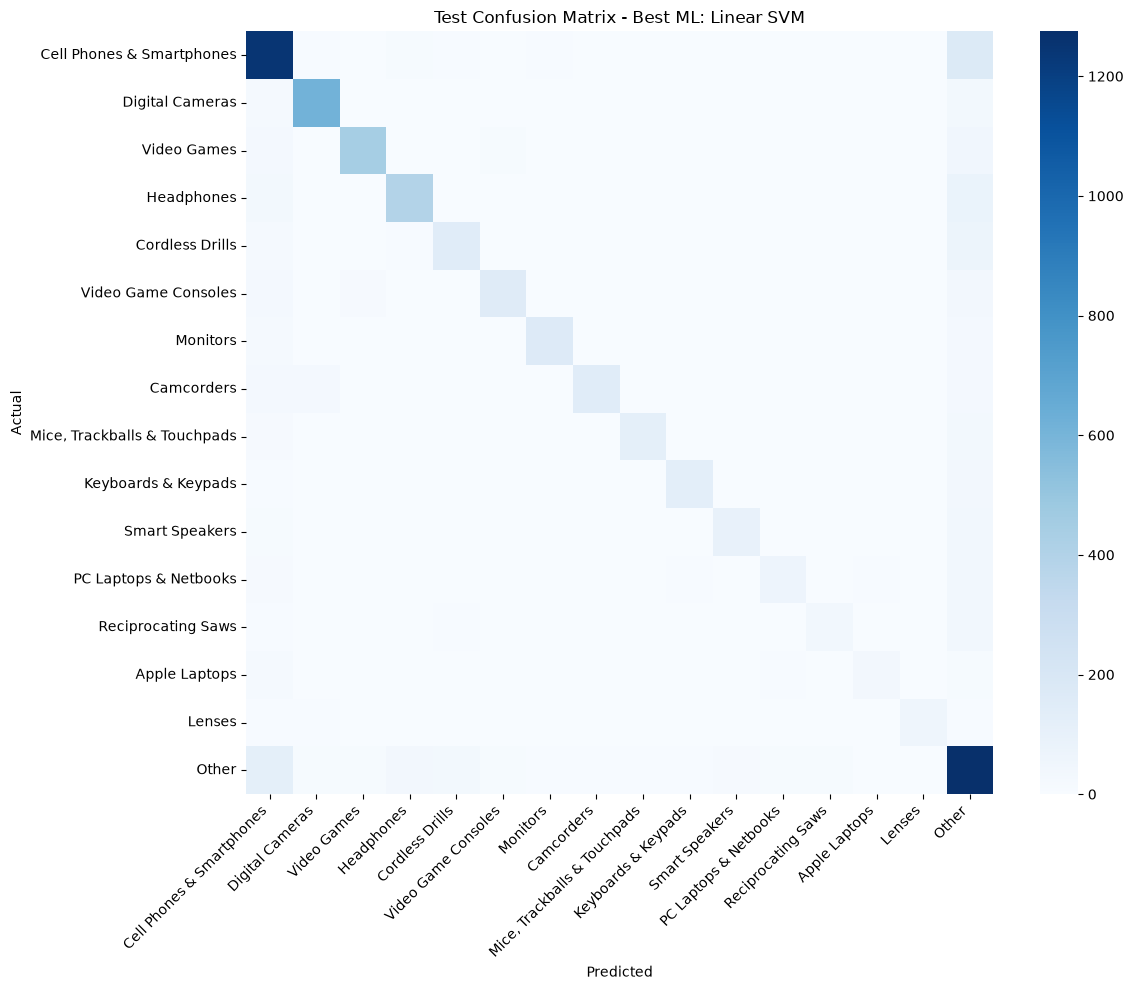

In [31]:
best_ml_pred = ml_predictions[best_ml_name]

if best_ml_name == "Linear SVM":
    best_ml_prob = ml_probabilities["Linear SVM (normalized scores)"]
elif best_ml_name in ml_probabilities:
    best_ml_prob = ml_probabilities[best_ml_name]
else:
    best_ml_prob = None

cm_ml = confusion_matrix(y_test, best_ml_pred, labels=np.arange(len(CLASS_ORDER)))

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_ml,
    annot=False,
    cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Test Confusion Matrix - Best ML: {best_ml_name}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_best_ml_confusion_matrix.png", dpi=180)
plt.show()

### Best ML Classification Report

This report makes per-class behavior visible instead of relying only on aggregate metrics.

In [32]:
print(
    classification_report(
        y_test,
        best_ml_pred,
        labels=np.arange(len(CLASS_ORDER)),
        target_names=CLASS_ORDER,
        zero_division=0,
    )
)

                              precision    recall  f1-score   support

   Cell Phones & Smartphones       0.76      0.84      0.80      1479
             Digital Cameras       0.90      0.90      0.90       685
                 Video Games       0.92      0.83      0.87       538
                  Headphones       0.84      0.77      0.80       517
             Cordless Drills       0.72      0.56      0.63       261
         Video Game Consoles       0.80      0.62      0.70       251
                    Monitors       0.87      0.71      0.79       235
                  Camcorders       0.88      0.64      0.74       227
Mice, Trackballs & Touchpads       0.89      0.64      0.75       187
         Keyboards & Keypads       0.86      0.71      0.78       180
              Smart Speakers       0.81      0.61      0.70       157
       PC Laptops & Netbooks       0.65      0.45      0.53       152
          Reciprocating Saws       0.69      0.43      0.53       101
               Appl

,feature,mean_abs_coefficient
7629,phone,8.771014
1473,camera,7.525381
3934,game,6.812401
6831,monitor,5.188064
6916,mouse,4.958948
5730,keyboard,4.771586
2996,drill,4.173535
10191,sound,4.153908
5597,iphone,4.112692
5107,headphones,3.935546


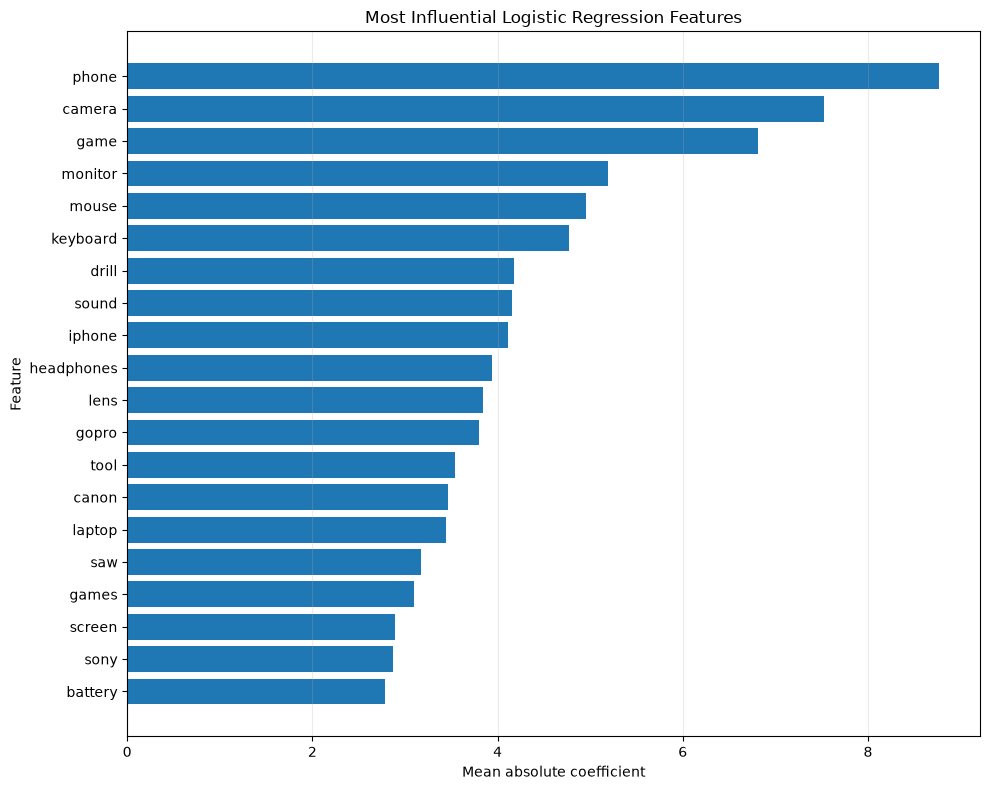

In [33]:
# Top text features for Logistic Regression, if the model exists.
if "Logistic Regression" in ml_models:
    lr_estimators = ml_models["Logistic Regression"].estimators_
    lr_coef = np.vstack([est.coef_.ravel() for est in lr_estimators])
    mean_abs_coef = np.mean(np.abs(lr_coef), axis=0)

    text_feature_names_final = list(selected_feature_names) + ["rating_auxiliary"]
    coef_df = pd.DataFrame({
        "feature": text_feature_names_final,
        "mean_abs_coefficient": mean_abs_coef,
    }).sort_values("mean_abs_coefficient", ascending=False)

    display(coef_df.head(25))

    plt.figure(figsize=(10, 8))
    top_coef = coef_df.head(20).sort_values("mean_abs_coefficient")
    plt.barh(top_coef["feature"], top_coef["mean_abs_coefficient"])
    plt.title("Most Influential Logistic Regression Features")
    plt.xlabel("Mean absolute coefficient")
    plt.ylabel("Feature")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "10_logistic_top_features.png", dpi=180)
    plt.show()

# 14. Deep Learning from Scratch - Concept

The lecture material defines Deep Learning as learning a composition of functions:

```text
X → f1 → H1 → f2 → H2 → f3 → prediction
```

For the supplied tutorial, the dense network follows:

```text
Z1 = XW1 + b1
H1 = ReLU(Z1)

Z2 = H1W2 + b2
H2 = ReLU(Z2)

Z3 = H2W3 + b3
ŷ = Softmax(Z3)
```

For the Comments application, the input is text, so we add an explicit learnable embedding
representation before the dense layers:

```text
Token IDs
   ↓
Embedding matrix
   ↓
Mean pooled representation
   ↓
Dense + ReLU
   ↓
Dense + ReLU
   ↓
Softmax
```

This keeps the fundamental lecture pattern while adapting the input representation
to text data.

# 15. Deep Learning Mathematics

For one mini-batch of token IDs:

```text
E = Embedding(TokenIDs)
H0 = MeanPool(E)
```

Then the dense part is:

```text
Z1 = H0 W1 + b1
H1 = ReLU(Z1)

Z2 = H1 W2 + b2
H2 = ReLU(Z2)

Z3 = H2 W3 + b3
P  = Softmax(Z3)
```

### Multi-class Cross-Entropy

For true class `y_i` and predicted class probabilities `P_i`:

```text
L = -(1/N) Σ log(P_i,y_i)
```

### Learning

The parameters are:

```text
θ = {Embedding, W1, b1, W2, b2, W3, b3}
```

and gradient descent applies:

```text
θ ← θ - η ∇θ L
```

For Softmax + cross-entropy, the output gradient is:

```text
dZ3 = (P - Y) / N
```

The rest follows the chain rule backward through the ReLU layers and mean-pooling
embedding representation.

The important conceptual flow remains:

```text
Forward → Loss → Backpropagation → Gradient Descent → Repeat
```

# 16. Prepare the Data for the NumPy Neural Network

We do **not** reuse the TF-IDF matrix as the neural-network input because the A2 text
representation requirement should be made explicit.

Instead, the neural network builds a vocabulary from the training reviews only:

```text
training text
   ↓
token frequency counting
   ↓
vocabulary
   ↓
integer token IDs
   ↓
fixed-length sequences
```

Special tokens:

```text
0 = PAD
1 = UNK
```

A review longer than the maximum sequence length is truncated for the neural-network
representation. This is a representation constraint, not deletion from the original CSV.

In [34]:
TOKEN_PATTERN = re.compile(r"[a-z0-9']+")
MAX_VOCAB_SIZE = 4000
MIN_TOKEN_FREQ = 2
MAX_LEN = 40

def tokenize(text):
    return TOKEN_PATTERN.findall(str(text).lower())

train_tokens = [tokenize(x) for x in X_train_text]

token_counter = Counter()
for toks in train_tokens:
    token_counter.update(toks)

vocab_tokens = [
    tok for tok, freq in token_counter.most_common()
    if freq >= MIN_TOKEN_FREQ
][: MAX_VOCAB_SIZE - 2]

PAD_ID = 0
UNK_ID = 1

token_to_id = {"<PAD>": PAD_ID, "<UNK>": UNK_ID}
for tok in vocab_tokens:
    token_to_id[tok] = len(token_to_id)

id_to_token = {idx: tok for tok, idx in token_to_id.items()}

print("Vocabulary size:", len(token_to_id))
print("Most common tokens:", token_counter.most_common(20))

Vocabulary size: 4000
Most common tokens: [('the', 54141), ('and', 34304), ('i', 32103), ('sep', 31329), ('a', 29932), ('to', 28405), ('it', 28231), ('is', 21781), ('great', 18356), ('for', 17656), ('this', 15325), ('of', 14473), ('with', 12237), ('my', 11710), ('good', 11529), ('in', 10805), ('you', 9861), ('but', 9371), ('that', 8827), ('very', 8377)]


In [35]:
def encode_text(text, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [token_to_id.get(tok, UNK_ID) for tok in tokens[:max_len]]

    if len(ids) < max_len:
        ids = ids + [PAD_ID] * (max_len - len(ids))

    return np.asarray(ids, dtype=np.int64)

X_train_ids = np.stack([encode_text(x) for x in X_train_text])
X_val_ids = np.stack([encode_text(x) for x in X_val_text])
X_test_ids = np.stack([encode_text(x) for x in X_test_text])

print("Token ID representation shapes:")
print("X_train_ids:", X_train_ids.shape)
print("X_val_ids  :", X_val_ids.shape)
print("X_test_ids :", X_test_ids.shape)

Token ID representation shapes:
X_train_ids: (31329, 40)
X_val_ids  : (6713, 40)
X_test_ids : (6714, 40)


### Text Representation Example

For one review we explicitly inspect:

```text
Raw review
   ↓
tokens
   ↓
token IDs
   ↓
embedding lookup
   ↓
mean pooled vector
```

The actual embedding weights are initialized randomly in the next step, then learned by
backpropagation. This is why the embedding is a **learned representation**, not a fixed
hand-crafted encoding.

In [36]:
demo_text = X_train_text[0]
demo_tokens = tokenize(demo_text)
demo_ids = encode_text(demo_text)

print("Demo text:")
print(demo_text[:1000])

print("\nFirst 25 tokens:")
print(demo_tokens[:25])

print("\nFirst 25 token IDs:")
print(demo_ids[:25])

print("\nSequence shape:", demo_ids.shape)

Demo text:
looks great with good features. [SEP] phone appears to be okay after looking at phone carefully several cracks have be discovered on the back of phone and the front have a small air crack going straight down the side.

First 25 tokens:
['looks', 'great', 'with', 'good', 'features', 'sep', 'phone', 'appears', 'to', 'be', 'okay', 'after', 'looking', 'at', 'phone', 'carefully', 'several', 'cracks', 'have', 'be', 'discovered', 'on', 'the', 'back', 'of']

First 25 token IDs:
[ 184   10   14   16  101    5   27 1312    7   40  924  140  189   47
   27 2806  402 3090   25   40 2620   23    2  164   13]

Sequence shape: (40,)


# 17. Step 1 - Implement Activation Functions

The hidden layers use **ReLU**:

```text
ReLU(x) = max(0, x)
```

The output layer uses **Softmax** because the task has multiple interest categories:

```text
Softmax(z_j) = exp(z_j) / Σ exp(z_k)
```

A stable Softmax subtracts the row maximum before exponentiation.

A derivative function for ReLU is required by manual backpropagation.

In [37]:
def relu(x):
    return np.maximum(0.0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float64)

def softmax(x):
    x = np.asarray(x, dtype=np.float64)
    shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Small activation-function verification
activation_demo = np.array([[-2.0, 0.0, 1.5]])
print("ReLU:", relu(activation_demo))
print("ReLU derivative:", relu_derivative(activation_demo))

softmax_demo = softmax(np.array([[1.0, 2.0, 3.0]]))
print("Softmax:", softmax_demo)
print("Probability sum:", softmax_demo.sum(axis=1))

ReLU: [[0.  0.  1.5]]
ReLU derivative: [[0. 0. 1.]]
Softmax: [[0.09003057 0.24472847 0.66524096]]
Probability sum: [1.]


# 18. Step 2 - Initialize the Network

The architecture is:

```text
MAX_LEN token IDs
      ↓
Embedding: vocabulary × 24
      ↓
Mean Pooling: 24
      ↓
Dense: 24 → 64
      ↓ ReLU
Dense: 64 → 32
      ↓ ReLU
Dense: 32 → 16
      ↓
Softmax
```

The lecture example uses He-style initialization for ReLU layers. We use the same idea
for the dense weights.

The embedding matrix is initialized with a small normal distribution and is learned
from the training objective.

In [38]:
DL_EMBED_DIM = 16
DL_HIDDEN_1 = 48
DL_HIDDEN_2 = 24
DL_OUTPUT_DIM = len(CLASS_ORDER)

class NumpyTextMLP:
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden1,
        hidden2,
        output_dim,
        seed=42,
    ):
        rng = np.random.default_rng(seed)

        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.output_dim = output_dim

        self.embedding = rng.normal(
            0.0, 0.05, size=(vocab_size, embed_dim)
        ).astype(np.float64)
        self.embedding[PAD_ID] = 0.0

        self.W1 = rng.normal(
            0.0, np.sqrt(2.0 / embed_dim),
            size=(embed_dim, hidden1)
        )
        self.b1 = np.zeros((1, hidden1))

        self.W2 = rng.normal(
            0.0, np.sqrt(2.0 / hidden1),
            size=(hidden1, hidden2)
        )
        self.b2 = np.zeros((1, hidden2))

        self.W3 = rng.normal(
            0.0, np.sqrt(2.0 / hidden2),
            size=(hidden2, output_dim)
        )
        self.b3 = np.zeros((1, output_dim))

    def parameter_shapes(self):
        return {
            "embedding": self.embedding.shape,
            "W1": self.W1.shape,
            "b1": self.b1.shape,
            "W2": self.W2.shape,
            "b2": self.b2.shape,
            "W3": self.W3.shape,
            "b3": self.b3.shape,
        }

    def forward(self, token_ids):
        token_ids = np.asarray(token_ids, dtype=np.int64)

        # Embedding lookup: (B, T) -> (B, T, D)
        emb = self.embedding[token_ids]

        mask = (token_ids != PAD_ID).astype(np.float64)
        lengths = np.maximum(mask.sum(axis=1, keepdims=True), 1.0)

        # Mean pooling over non-padding tokens.
        pooled = (emb * mask[:, :, None]).sum(axis=1) / lengths

        z1 = pooled @ self.W1 + self.b1
        h1 = relu(z1)

        z2 = h1 @ self.W2 + self.b2
        h2 = relu(z2)

        z3 = h2 @ self.W3 + self.b3
        prob = softmax(z3)

        cache = {
            "token_ids": token_ids,
            "emb": emb,
            "mask": mask,
            "lengths": lengths,
            "pooled": pooled,
            "z1": z1,
            "h1": h1,
            "z2": z2,
            "h2": h2,
            "z3": z3,
            "prob": prob,
        }
        return prob, cache

    def cross_entropy(self, y_true, prob):
        y_true = np.asarray(y_true, dtype=np.int64)
        prob = np.asarray(prob, dtype=np.float64)
        clipped = np.clip(prob[np.arange(len(y_true)), y_true], 1e-12, 1.0)
        return float(-np.mean(np.log(clipped)))

    def backward(self, y_true, cache):
        token_ids = cache["token_ids"]
        emb = cache["emb"]
        mask = cache["mask"]
        lengths = cache["lengths"]
        pooled = cache["pooled"]
        h1 = cache["h1"]
        z1 = cache["z1"]
        h2 = cache["h2"]
        prob = cache["prob"]

        batch_size = len(y_true)

        # Softmax + cross entropy
        dZ3 = prob.copy()
        dZ3[np.arange(batch_size), y_true] -= 1.0
        dZ3 /= batch_size

        dW3 = h2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dH2 = dZ3 @ self.W3.T
        dZ2 = dH2 * relu_derivative(cache["z2"])

        dW2 = h1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dH1 = dZ2 @ self.W2.T
        dZ1 = dH1 * relu_derivative(z1)

        dW1 = pooled.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        dPooled = dZ1 @ self.W1.T

        # Backpropagate through mean pooling to each token embedding.
        dEmb = (
            dPooled[:, None, :]
            / lengths[:, :, None]
            * mask[:, :, None]
        )

        dEmbedding = np.zeros_like(self.embedding)
        flat_ids = token_ids.reshape(-1)
        flat_grad = dEmb.reshape(-1, self.embed_dim)
        valid = flat_ids != PAD_ID

        np.add.at(
            dEmbedding,
            flat_ids[valid],
            flat_grad[valid],
        )

        return {
            "dEmbedding": dEmbedding,
            "dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2,
            "dW3": dW3,
            "db3": db3,
        }

    def update(self, gradients, learning_rate):
        self.embedding -= learning_rate * gradients["dEmbedding"]
        self.embedding[PAD_ID] = 0.0

        self.W1 -= learning_rate * gradients["dW1"]
        self.b1 -= learning_rate * gradients["db1"]

        self.W2 -= learning_rate * gradients["dW2"]
        self.b2 -= learning_rate * gradients["db2"]

        self.W3 -= learning_rate * gradients["dW3"]
        self.b3 -= learning_rate * gradients["db3"]

    def predict_proba(self, token_ids):
        prob, _ = self.forward(token_ids)
        return prob

    def predict(self, token_ids):
        return np.argmax(self.predict_proba(token_ids), axis=1)

model_demo = NumpyTextMLP(
    vocab_size=len(token_to_id),
    embed_dim=DL_EMBED_DIM,
    hidden1=DL_HIDDEN_1,
    hidden2=DL_HIDDEN_2,
    output_dim=DL_OUTPUT_DIM,
    seed=SEED,
)

print("Network parameter shapes:")
display(pd.DataFrame(
    [{"parameter": k, "shape": v} for k, v in model_demo.parameter_shapes().items()]
))

Network parameter shapes:


,parameter,shape
0,embedding,"(4000, 16)"
1,W1,"(16, 48)"
2,b1,"(1, 48)"
3,W2,"(48, 24)"
4,b2,"(1, 24)"
5,W3,"(24, 16)"
6,b3,"(1, 16)"


# 19. Step 3 - Forward Propagation

The forward pass applies the functions from input to output:

```text
Token IDs
   ↓
Embedding lookup
   ↓
Mean pooling
   ↓
Z1 = H0 W1 + b1
   ↓
H1 = ReLU(Z1)
   ↓
Z2 = H1 W2 + b2
   ↓
H2 = ReLU(Z2)
   ↓
Z3 = H2 W3 + b3
   ↓
P = Softmax(Z3)
```

The intermediate values are stored in a cache because Step 5 backpropagation needs them.

### Verification required

We explicitly check:
- output shape
- each probability row sums to approximately 1
- no NaN/Inf values are present

In [39]:
demo_ids_batch = X_train_ids[:4]
demo_model = NumpyTextMLP(
    vocab_size=len(token_to_id),
    embed_dim=DL_EMBED_DIM,
    hidden1=DL_HIDDEN_1,
    hidden2=DL_HIDDEN_2,
    output_dim=DL_OUTPUT_DIM,
    seed=SEED,
)

demo_prob, demo_cache = demo_model.forward(demo_ids_batch)

print("Input token-ID shape:", demo_ids_batch.shape)
print("Embedding batch shape:", demo_cache["emb"].shape)
print("Mean-pooled shape:", demo_cache["pooled"].shape)
print("Output probability shape:", demo_prob.shape)
print("Probability sums:", np.round(demo_prob.sum(axis=1), 6))
print("Contains NaN:", np.isnan(demo_prob).any())
print("Contains Inf:", np.isinf(demo_prob).any())

Input token-ID shape: (4, 40)
Embedding batch shape: (4, 40, 16)
Mean-pooled shape: (4, 16)
Output probability shape: (4, 16)
Probability sums: [1. 1. 1. 1.]
Contains NaN: False
Contains Inf: False


# 20. Step 4 - Cross-Entropy Loss

For one review:

```text
Loss = -log(P(correct class))
```

For the mini-batch:

```text
L = -(1/N) Σ log(P_i,y_i)
```

A correct high-probability prediction produces a small loss; assigning a small probability
to the true class produces a larger loss.

### Verification required

We compute the loss on the small forward-pass example before training.

In [40]:
demo_y = y_train[:4]

demo_loss = demo_model.cross_entropy(demo_y, demo_prob)

print("True class IDs:", demo_y)
print("Predicted probabilities for the true classes:")
print(np.round(demo_prob[np.arange(len(demo_y)), demo_y], 6))
print("Example cross-entropy loss:", round(float(demo_loss), 6))

True class IDs: [0 9 7 0]
Predicted probabilities for the true classes:
[0.062388 0.06137  0.061276 0.062546]
Example cross-entropy loss: 2.782362


# 21. Step 5 - Backpropagation

Backpropagation is the systematic application of the chain rule.

The lecture's core idea is:

```text
Loss
 ↓
output layer
 ↓
hidden layer 2
 ↓
hidden layer 1
 ↓
input representation
```

For Softmax + cross-entropy:

```text
dZ3 = (P - Y) / N
```

Then:

```text
dW3 = H2.T dZ3
dH2 = dZ3 W3.T
dZ2 = dH2 ⊙ ReLU'(Z2)
dW2 = H1.T dZ2
dH1 = dZ2 W2.T
dZ1 = dH1 ⊙ ReLU'(Z1)
dW1 = H0.T dZ1
```

For this text model, the gradient also continues into the embedding representation
through the mean-pooling operation.

### Verification required

The next cell prints the shape of every gradient tensor.

In [41]:
demo_gradients = demo_model.backward(demo_y, demo_cache)

for name, value in demo_gradients.items():
    print(f"{name:12s}: {value.shape} | finite={np.isfinite(value).all()}")

dEmbedding  : (4000, 16) | finite=True
dW1         : (16, 48) | finite=True
db1         : (1, 48) | finite=True
dW2         : (48, 24) | finite=True
db2         : (1, 24) | finite=True
dW3         : (24, 16) | finite=True
db3         : (1, 16) | finite=True


# 22. Step 6 - Gradient Descent

Once the gradients are known, every trainable parameter is updated:

```text
W ← W - η dW
b ← b - η db
Embedding ← Embedding - η dEmbedding
```

This is the same optimization principle as the lecture's dense-network example.

### Verification required

We perform one real gradient update on the small demonstration batch and compare the loss
before and after the update.

In [42]:
update_model = NumpyTextMLP(
    vocab_size=len(token_to_id),
    embed_dim=DL_EMBED_DIM,
    hidden1=DL_HIDDEN_1,
    hidden2=DL_HIDDEN_2,
    output_dim=DL_OUTPUT_DIM,
    seed=SEED,
)

prob_before, cache_before = update_model.forward(demo_ids_batch)
loss_before = update_model.cross_entropy(demo_y, prob_before)

grads_before = update_model.backward(demo_y, cache_before)

LEARNING_RATE_CHECK = 0.02
update_model.update(grads_before, LEARNING_RATE_CHECK)

prob_after, _ = update_model.forward(demo_ids_batch)
loss_after = update_model.cross_entropy(demo_y, prob_after)

print("Loss before one update:", round(loss_before, 6))
print("Loss after  one update:", round(loss_after, 6))
print("Loss change:", round(loss_after - loss_before, 6))

Loss before one update: 2.782362
Loss after  one update: 2.76784
Loss change: -0.014523


# 23. Step 7 - Training Loop

The complete training cycle is:

```text
Forward
   ↓
Cross-Entropy Loss
   ↓
Backpropagation
   ↓
Gradient Descent
   ↓
Repeat
```

A mini-batch loop is used because the full text dataset is larger than the small
lecture example.

Validation loss is recorded after every epoch:

```text
Training loss      → learning on seen data
Validation loss    → generalization on unseen data
```

The test set remains untouched until Step 9.

In [43]:
DL_BATCH_SIZE = 512
DL_EPOCHS = 6
DL_LEARNING_RATE = 0.05

dl_model = NumpyTextMLP(
    vocab_size=len(token_to_id),
    embed_dim=DL_EMBED_DIM,
    hidden1=DL_HIDDEN_1,
    hidden2=DL_HIDDEN_2,
    output_dim=DL_OUTPUT_DIM,
    seed=SEED,
)

train_loss_history = []
val_loss_history = []

num_train = len(X_train_ids)

for epoch in range(DL_EPOCHS):
    epoch_rng = np.random.default_rng(SEED + epoch)
    indices = epoch_rng.permutation(num_train)

    batch_losses = []

    for start_idx in range(0, num_train, DL_BATCH_SIZE):
        batch_idx = indices[start_idx : start_idx + DL_BATCH_SIZE]
        X_batch = X_train_ids[batch_idx]
        y_batch = y_train[batch_idx]

        batch_prob, batch_cache = dl_model.forward(X_batch)
        batch_loss = dl_model.cross_entropy(y_batch, batch_prob)

        gradients = dl_model.backward(y_batch, batch_cache)
        dl_model.update(gradients, DL_LEARNING_RATE)

        batch_losses.append(batch_loss)

    # Full training loss is sampled for speed; validation loss uses the full validation set.
    loss_check_idx = indices[: min(5000, len(indices))]
    train_prob_check = dl_model.predict_proba(X_train_ids[loss_check_idx])
    train_loss = dl_model.cross_entropy(y_train[loss_check_idx], train_prob_check)

    val_prob = dl_model.predict_proba(X_val_ids)
    val_loss = dl_model.cross_entropy(y_val, val_prob)

    train_loss_history.append(float(train_loss))
    val_loss_history.append(float(val_loss))

    print(
        f"Epoch {epoch + 1:02d}/{DL_EPOCHS} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}"
    )

Epoch 01/6 | Train Loss = 2.4162 | Val Loss = 2.4147
Epoch 02/6 | Train Loss = 2.3484 | Val Loss = 2.3480
Epoch 03/6 | Train Loss = 2.3578 | Val Loss = 2.3333
Epoch 04/6 | Train Loss = 2.3275 | Val Loss = 2.3256
Epoch 05/6 | Train Loss = 2.3022 | Val Loss = 2.3192
Epoch 06/6 | Train Loss = 2.3157 | Val Loss = 2.3131


### Training Curve

The expected pattern is:

- training loss should decrease as the network learns;
- validation loss should decrease while generalization improves;
- a widening train/validation gap can indicate overfitting.

The exact conclusion must be based on the curve produced by the executed notebook.

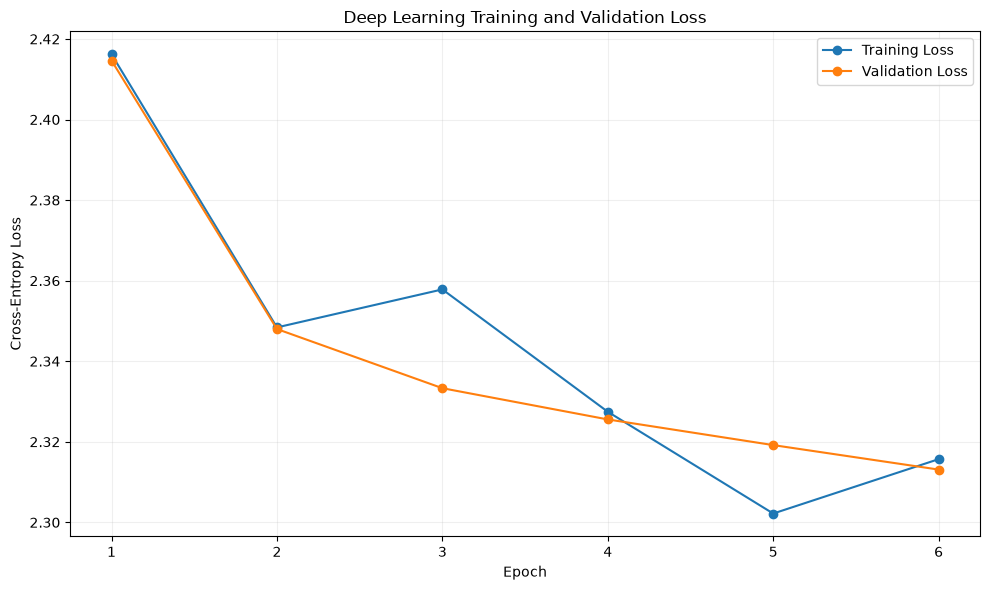

In [44]:
plt.figure(figsize=(10, 6))
epochs_axis = np.arange(1, DL_EPOCHS + 1)

plt.plot(epochs_axis, train_loss_history, marker="o", label="Training Loss")
plt.plot(epochs_axis, val_loss_history, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Deep Learning Training and Validation Loss")
plt.xticks(epochs_axis)
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "11_dl_loss_curve.png", dpi=180)
plt.show()

# 24. Step 8 - Prediction

After training, the network returns:

```text
P(class 0), P(class 1), ..., P(class 15)
```

The class with the largest probability becomes the predicted interest category.

Unlike the SVM score visualization, the neural network's Softmax outputs are proper
class probabilities because they are normalized to sum to 1.

The test set is used here for the first time in the Deep Learning section.

In [45]:
final_dl_prob = dl_model.predict_proba(X_test_ids)
final_dl_pred = np.argmax(final_dl_prob, axis=1)

print("Prediction shape:", final_dl_pred.shape)
print("Probability matrix shape:", final_dl_prob.shape)

print("\nFirst 5 test predictions:")
sample_pred_df = pd.DataFrame({
    "Actual": [ID_TO_CLASS[i] for i in y_test[:5]],
    "Predicted": [ID_TO_CLASS[i] for i in final_dl_pred[:5]],
    "Confidence": np.max(final_dl_prob[:5], axis=1).round(4),
})

display(sample_pred_df)

print("Probability sums for first 5 rows:")
print(np.round(final_dl_prob[:5].sum(axis=1), 6))

Prediction shape: (6714,)
Probability matrix shape: (6714, 16)

First 5 test predictions:


,Actual,Predicted,Confidence
0,Video Games,Other,0.2497
1,Other,Other,0.2291
2,Smart Speakers,Other,0.2389
3,Video Games,Other,0.2390
4,"Mice, Trackballs & Touchpads",Other,0.2343


Probability sums for first 5 rows:
[1. 1. 1. 1. 1.]


# 25. Step 9 - Evaluation

The final Deep Learning model is evaluated on the same untouched test set as the three
traditional ML models.

Metrics:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Balanced Accuracy
- One-vs-Rest ROC-AUC

A confusion matrix is also shown.

The purpose is to make a fair, simultaneous four-model comparison possible.

,Accuracy,Precision_macro,Recall_macro,F1_macro,Balanced_Accuracy,ROC_AUC_OVR_macro,Model,Training_Time_sec,Final_Training_Loss
0,0.267948,0.049068,0.072301,0.042508,0.072301,0.595601,Deep Learning - NumPy,NaN,2.315691


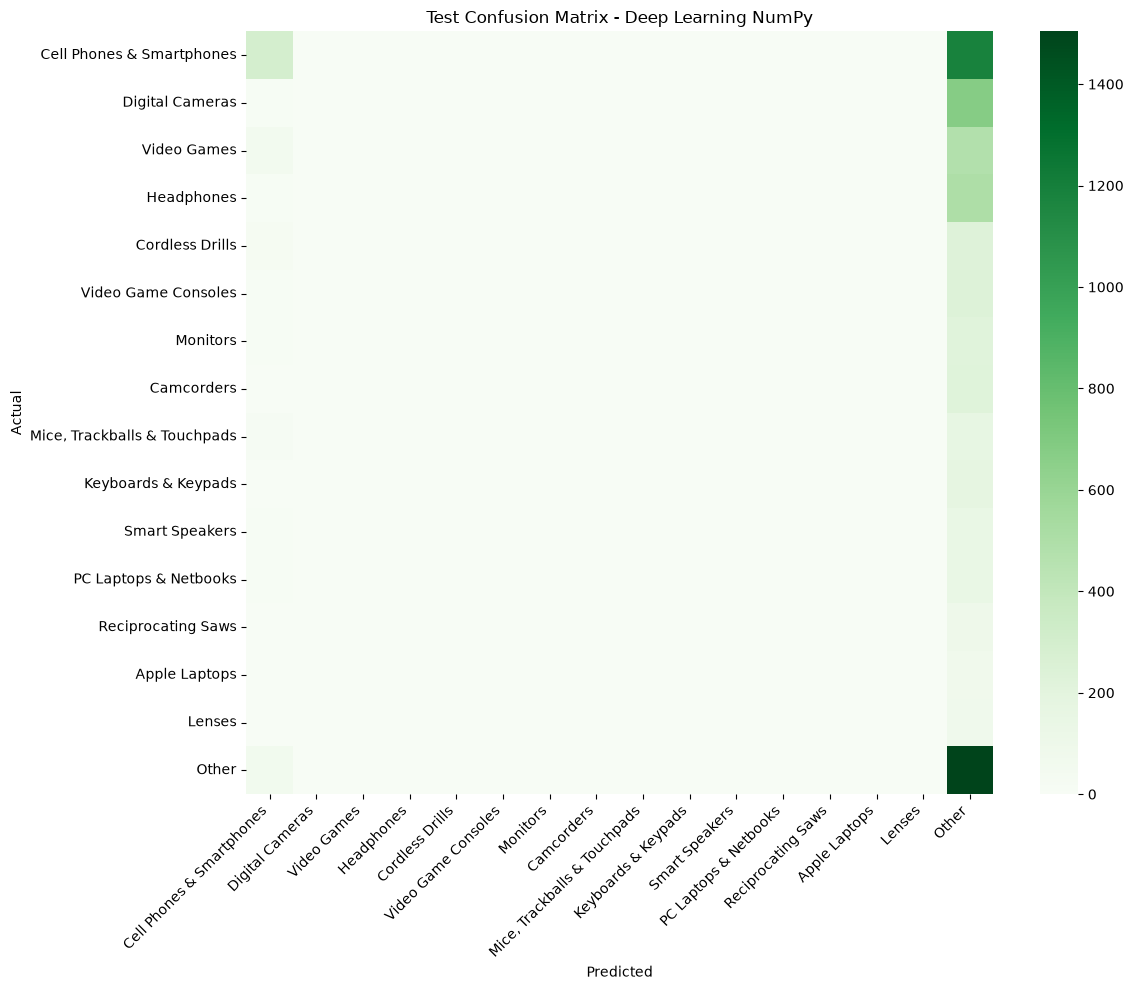

In [46]:
final_dl_metrics = classification_metrics(
    y_test,
    final_dl_pred,
    final_dl_prob,
)

final_dl_metrics["Model"] = "Deep Learning - NumPy"
final_dl_metrics["Training_Time_sec"] = np.nan
final_dl_metrics["Final_Training_Loss"] = train_loss_history[-1]

display(pd.DataFrame([final_dl_metrics]))

cm_dl = confusion_matrix(
    y_test,
    final_dl_pred,
    labels=np.arange(len(CLASS_ORDER)),
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_dl,
    annot=False,
    cmap="Greens",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix - Deep Learning NumPy")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_dl_confusion_matrix.png", dpi=180)
plt.show()

# 26. Final Comparison - All Four Models Together

This is the central A3 comparison.

The four models are evaluated **together**:

1. Logistic Regression
2. Linear SVM
3. Multinomial Naive Bayes
4. Deep Learning - NumPy

There is no two-stage comparison where a "best ML model" is compared against Deep Learning
after the fact. All four are placed in the same final table and visualization.

All four use the same held-out test set and the same core metrics.

In [47]:
final_four = pd.concat([
    traditional_results[[
        "Model",
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "Balanced_Accuracy",
        "ROC_AUC_OVR_macro",
        "Training_Time_sec",
    ]],
    pd.DataFrame([{
        "Model": "Deep Learning - NumPy",
        "Accuracy": final_dl_metrics["Accuracy"],
        "Precision_macro": final_dl_metrics["Precision_macro"],
        "Recall_macro": final_dl_metrics["Recall_macro"],
        "F1_macro": final_dl_metrics["F1_macro"],
        "Balanced_Accuracy": final_dl_metrics["Balanced_Accuracy"],
        "ROC_AUC_OVR_macro": final_dl_metrics["ROC_AUC_OVR_macro"],
        "Training_Time_sec": np.nan,
    }]),
], ignore_index=True)

final_four = final_four.sort_values(
    "F1_macro",
    ascending=False,
).reset_index(drop=True)

display(final_four)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Balanced_Accuracy,ROC_AUC_OVR_macro,Training_Time_sec
0,Linear SVM,0.766607,0.799829,0.666386,0.720912,0.666386,0.950790,7.503092
1,Logistic Regression,0.764224,0.858607,0.640212,0.717623,0.640212,0.957979,5.313868
2,Multinomial Naive Bayes,0.714030,0.894670,0.501026,0.584423,0.501026,0.937572,0.036589
3,Deep Learning - NumPy,0.267948,0.049068,0.072301,0.042508,0.072301,0.595601,NaN


### How the final model comparison should be interpreted

Macro F1 is used as the main ranking metric, but the final decision should not be made
from one number alone.

We examine:

- F1 for overall multi-class balance
- Recall for missed interests
- Accuracy for overall correctness
- ROC-AUC for ranking/discrimination where meaningful
- Training time as a deployment consideration

A model can be the strongest predictive model without being the cheapest model to deploy.

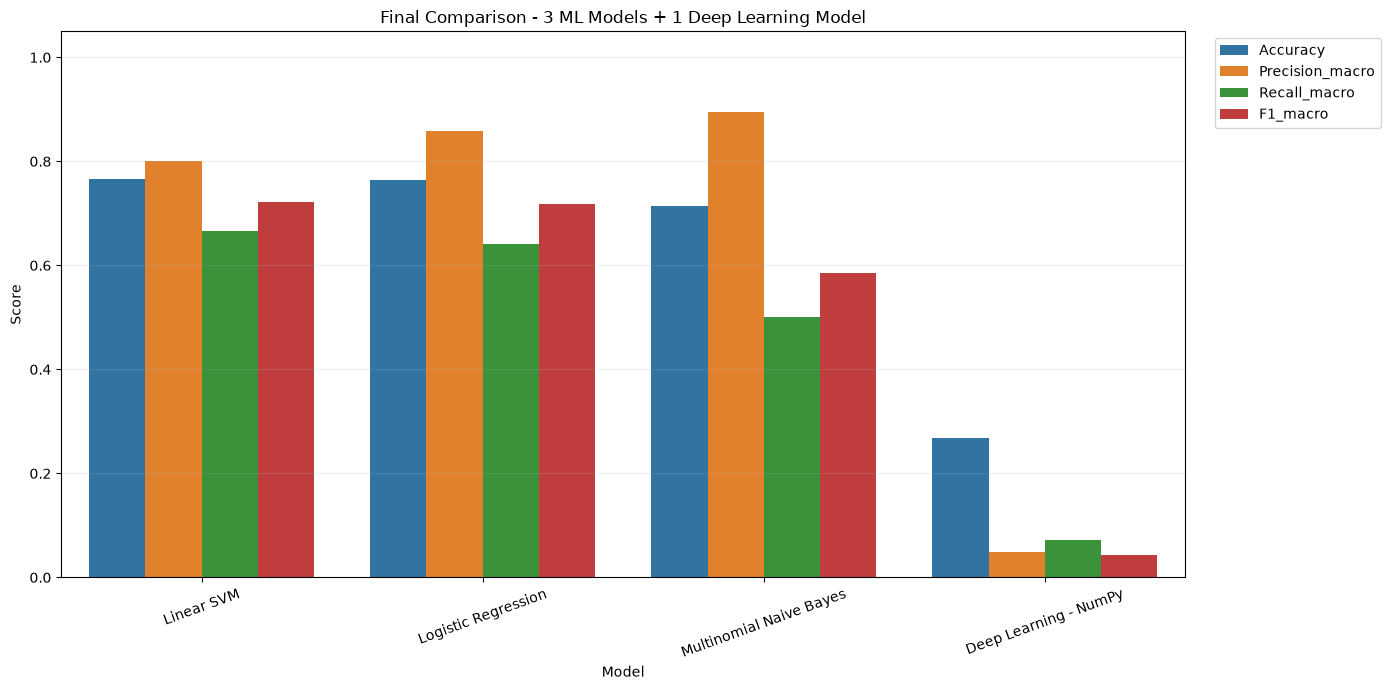

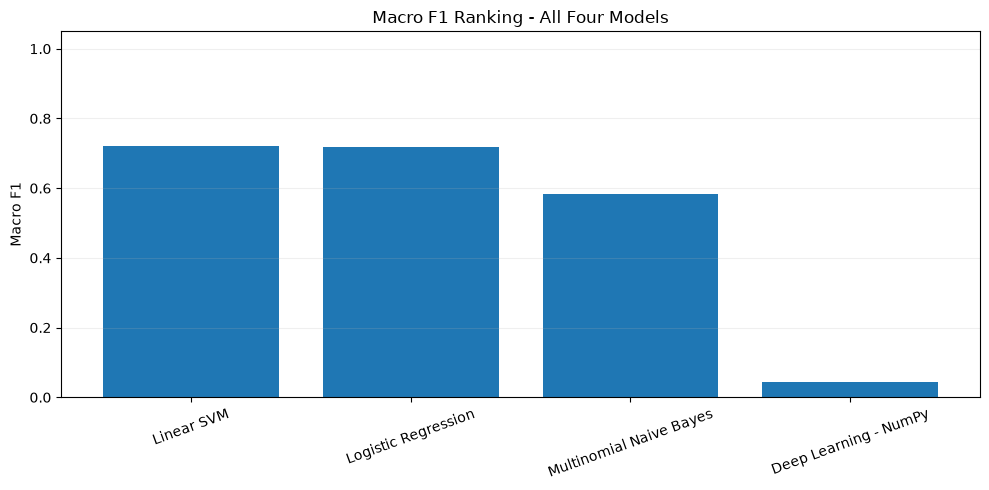

In [48]:
comparison_melt = final_four.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
    ],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=comparison_melt,
    x="Model",
    y="Score",
    hue="Metric",
)

plt.ylim(0, 1.05)
plt.title("Final Comparison - 3 ML Models + 1 Deep Learning Model")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_four_model_comparison.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(
    final_four["Model"],
    final_four["F1_macro"],
)

plt.ylim(0, 1.05)
plt.title("Macro F1 Ranking - All Four Models")
plt.ylabel("Macro F1")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_four_model_macro_f1_ranking.png", dpi=180)
plt.show()

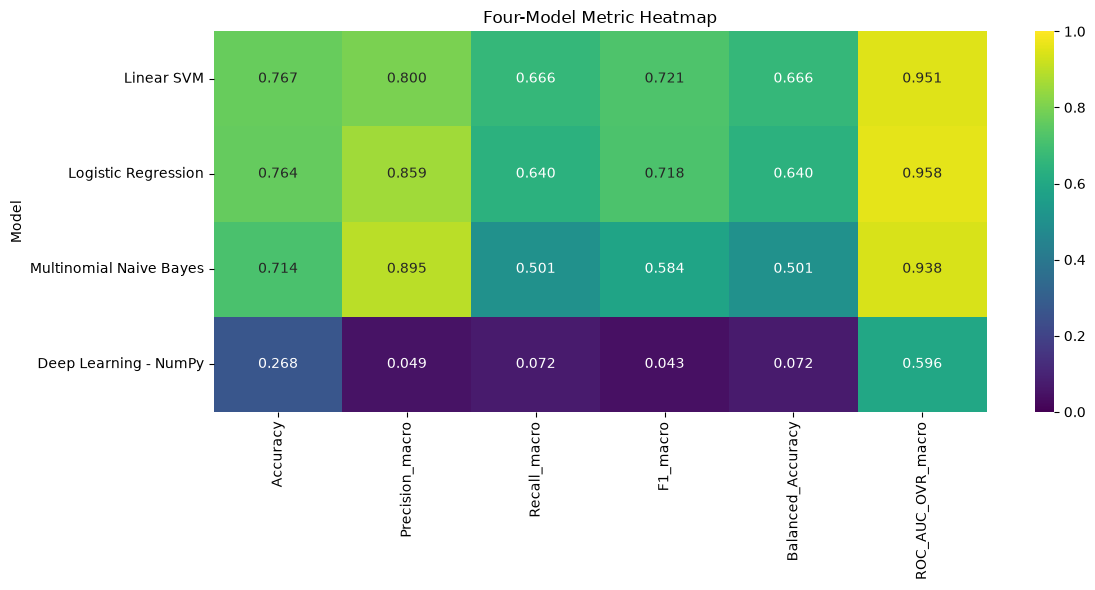

In [49]:
metric_heatmap = final_four.set_index("Model")[
    [
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "Balanced_Accuracy",
        "ROC_AUC_OVR_macro",
    ]
]

plt.figure(figsize=(12, 6))
sns.heatmap(
    metric_heatmap,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

plt.title("Four-Model Metric Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "15_four_model_metric_heatmap.png", dpi=180)
plt.show()

,Model,Correct,Incorrect
0,Logistic Regression,5131,1583
1,Linear SVM,5147,1567
2,Multinomial Naive Bayes,4794,1920
3,Deep Learning - NumPy,1799,4915


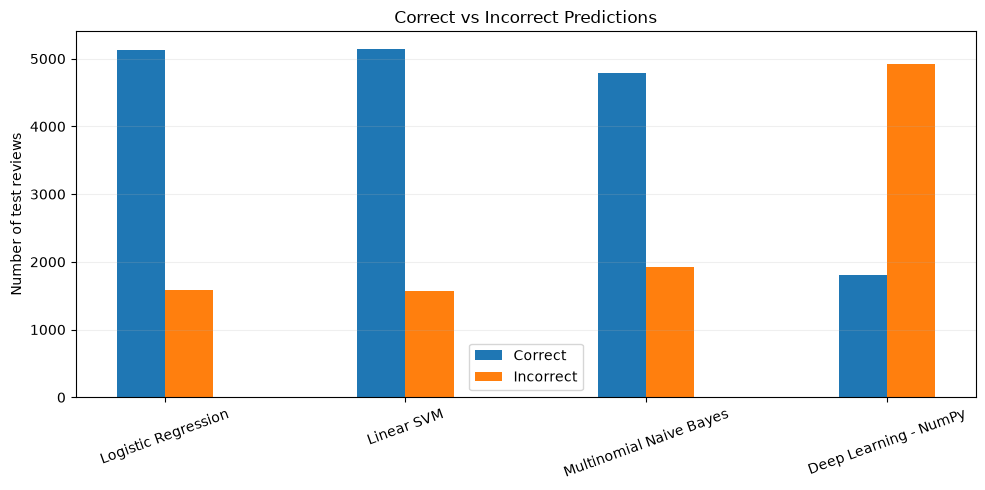

In [50]:
# Actual vs predicted class agreement by model.
prediction_table = pd.DataFrame({
    "Actual": y_test,
    "Logistic Regression": ml_predictions["Logistic Regression"],
    "Linear SVM": ml_predictions["Linear SVM"],
    "Multinomial Naive Bayes": ml_predictions["Multinomial Naive Bayes"],
    "Deep Learning - NumPy": final_dl_pred,
})

agreement_rows = []

for model_name in prediction_table.columns[1:]:
    agreement_rows.append({
        "Model": model_name,
        "Correct": int((prediction_table["Actual"] == prediction_table[model_name]).sum()),
        "Incorrect": int((prediction_table["Actual"] != prediction_table[model_name]).sum()),
    })

agreement_df = pd.DataFrame(agreement_rows)
display(agreement_df)

plt.figure(figsize=(10, 5))
width = 0.2
x = np.arange(len(agreement_df))

plt.bar(x - 1.5 * width, agreement_df["Correct"], width, label="Correct")
plt.bar(x - 0.5 * width, agreement_df["Incorrect"], width, label="Incorrect")

plt.xticks(x - width, agreement_df["Model"], rotation=20)
plt.ylabel("Number of test reviews")
plt.title("Correct vs Incorrect Predictions")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "16_correct_incorrect_predictions.png", dpi=180)
plt.show()

### Confusion-Matrix Comparison

The four confusion matrices use the same class order and the same test set.

This visualization is intentionally included because category-level accuracy can hide
which product interests are being confused.

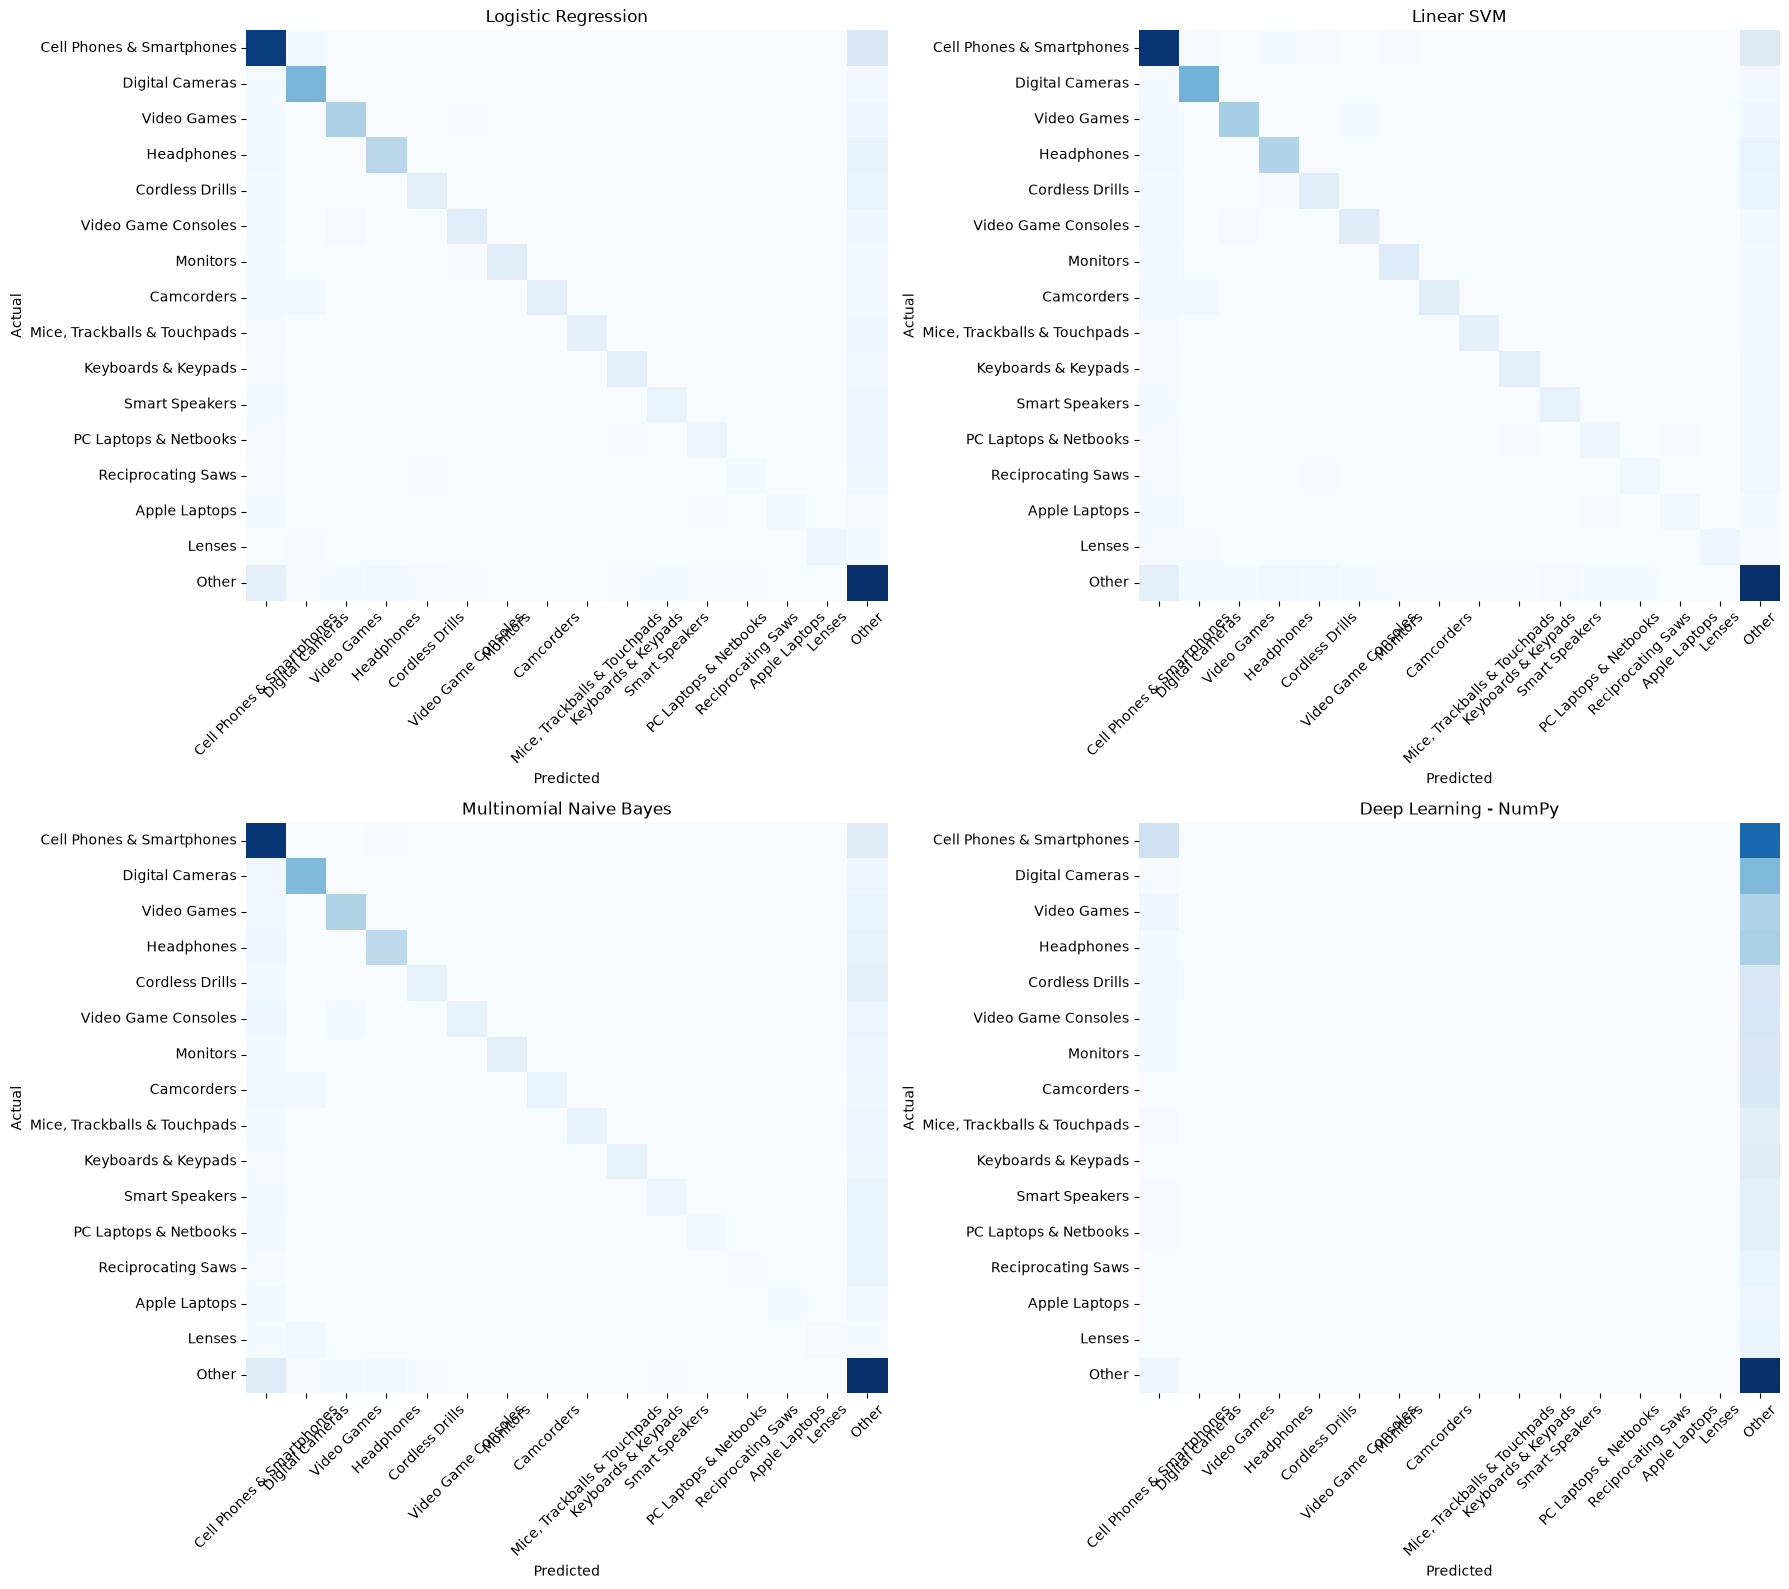

In [51]:
all_prediction_maps = {
    "Logistic Regression": ml_predictions["Logistic Regression"],
    "Linear SVM": ml_predictions["Linear SVM"],
    "Multinomial Naive Bayes": ml_predictions["Multinomial Naive Bayes"],
    "Deep Learning - NumPy": final_dl_pred,
}

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, all_prediction_maps.items()):
    cm = confusion_matrix(y_test, pred, labels=np.arange(len(CLASS_ORDER)))
    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        cbar=False,
        xticklabels=CLASS_ORDER,
        yticklabels=CLASS_ORDER,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "17_all_four_confusion_matrices.png", dpi=180)
plt.show()

# 27. Probability / Confidence Visualization

For deployment, it is useful to show not only the predicted class but also model confidence.

- Logistic Regression and Naive Bayes provide class probabilities.
- Deep Learning Softmax provides class probabilities.
- Linear SVM provides decision scores rather than calibrated probabilities; the notebook
  uses normalized scores only for visualization and explicitly does not call them calibrated
  probabilities.

The next cell compares the top predicted confidence for the best available deployed models.

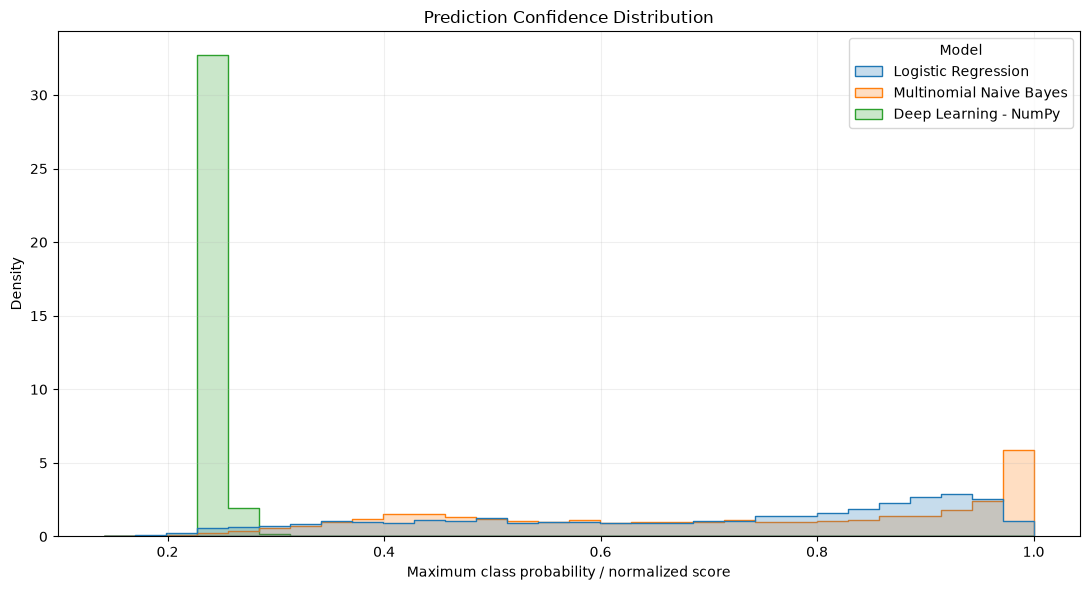

In [52]:
def get_model_probabilities(model_name):
    if model_name == "Deep Learning - NumPy":
        return final_dl_prob, True

    if model_name == "Linear SVM":
        return ml_probabilities["Linear SVM (normalized scores)"], False

    return ml_probabilities[model_name], True

probability_models = [
    "Logistic Regression",
    "Multinomial Naive Bayes",
    "Deep Learning - NumPy",
]

confidence_df = []

for model_name in probability_models:
    prob, is_probability = get_model_probabilities(model_name)
    confidence_df.append(
        pd.DataFrame({
            "Model": model_name,
            "Confidence": np.max(prob, axis=1),
            "Is calibrated probability": is_probability,
        })
    )

confidence_df = pd.concat(confidence_df, ignore_index=True)

plt.figure(figsize=(11, 6))
sns.histplot(
    data=confidence_df,
    x="Confidence",
    hue="Model",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Maximum class probability / normalized score")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "18_confidence_distribution.png", dpi=180)
plt.show()

# 28. Error Analysis

A strong AI workflow does not stop at aggregate metrics.

For text classification, common failure modes include:

- semantically similar product categories;
- reviews that mention several product types;
- very short reviews with little discriminative vocabulary;
- reviews assigned to `Other` because the raw category is rare;
- highly positive/negative language that carries sentiment but not category identity.

The following cells identify the most common actual → predicted confusions and show example
misclassified reviews.

In [53]:
best_four_name = final_four.iloc[0]["Model"]
best_four_pred = all_prediction_maps[best_four_name]

error_pairs = (
    pd.DataFrame({
        "Actual": [ID_TO_CLASS[i] for i in y_test],
        "Predicted": [ID_TO_CLASS[i] for i in best_four_pred],
    })
    .query("Actual != Predicted")
    .value_counts(["Actual", "Predicted"])
    .reset_index(name="count")
    .head(20)
)

display(error_pairs)

,Actual,Predicted,count
0,Cell Phones & Smartphones,Other,173
1,Other,Cell Phones & Smartphones,121
2,Headphones,Other,80
3,Cordless Drills,Other,70
4,Video Games,Other,49
5,PC Laptops & Netbooks,Other,42
6,Reciprocating Saws,Other,42
7,Smart Speakers,Other,40
8,Other,Headphones,39
9,Video Game Consoles,Other,39


In [54]:
misclassified_idx = np.where(y_test != best_four_pred)[0][:12]

error_examples = test_df.iloc[misclassified_idx][
    ["category", "review title", "review content", "rating", "interest_category"]
].copy()

error_examples["Predicted"] = [ID_TO_CLASS[i] for i in best_four_pred[misclassified_idx]]

display(error_examples)

,category,review title,review content,rating,interest_category,Predicted
15374,Camcorders,Adventure Cam 7 UltraProX,Great item... provides same quality and featur...,5,Camcorders,Other
27335,Video Games,Awesome,In like brand new condition.,5,Video Games,Video Game Consoles
10829,Calculators,Hp prime,Bought it so I could down load pictures on to ...,4,Other,Digital Cameras
16679,Media Streamers,Bueno,"Buen producto, fácil de usar",5,Other,Cell Phones & Smartphones
21678,Headphones,Great product,Works like new thank you!!!,5,Headphones,Cell Phones & Smartphones
37131,Digital Cameras,Great,Product came as described,5,Digital Cameras,Other
42609,Cordless Drills,TRUSTWORTHY,very good place to buy from. They refuned mone...,5,Cordless Drills,Cell Phones & Smartphones
34477,PC Laptops & Netbooks,very good LP,Excellent,5,PC Laptops & Netbooks,Other
44736,Racks & Holders,Bad description.,Made from cheap materials...,2,Other,Cell Phones & Smartphones
34003,Motherboards,this MB works great!!!!,"A little costly for a used as is item, but ope...",4,Other,"Mice, Trackballs & Touchpads"


# 29. Interpreting the Four Models

## Logistic Regression

Strengths:
- strong baseline for high-dimensional TF-IDF;
- fast inference;
- directly interpretable coefficients;
- native class probabilities.

Weakness:
- decision boundaries are linear in the selected TF-IDF feature space.

## Linear SVM

Strengths:
- efficient for large sparse text representations;
- strong large-margin classifier;
- often competitive with Logistic Regression on text.

Weakness:
- `LinearSVC` does not provide calibrated probabilities directly.

## Multinomial Naive Bayes

Strengths:
- very fast;
- simple;
- effective baseline for token-frequency-like representations.

Weakness:
- relies on the conditional-independence assumptions of Naive Bayes.

## Deep Learning - NumPy

Strengths:
- learns an internal text representation through the embedding matrix;
- captures nonlinear transformations through multiple ReLU layers;
- follows the complete From-Scratch learning cycle:
  `Forward → Loss → Backpropagation → Gradient Descent`.

Weakness:
- manual NumPy training is much less optimized than production Deep Learning frameworks;
- training quality depends on vocabulary, sequence length, architecture, learning rate, and
  number of epochs;
- the mean-pooling design loses word-order information after the embedding stage.

# 30. Final Model Ranking

The table below is the single four-model result that should be used for the report.

The model is ranked by Macro F1, but Accuracy, Recall, ROC-AUC, and training cost remain visible.

A deployment decision should consider both predictive quality and operational constraints.

In [55]:
final_four_ranked = final_four.copy()
final_four_ranked.insert(0, "Rank", np.arange(1, len(final_four_ranked) + 1))

display(final_four_ranked)

,Rank,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Balanced_Accuracy,ROC_AUC_OVR_macro,Training_Time_sec
0,1,Linear SVM,0.766607,0.799829,0.666386,0.720912,0.666386,0.950790,7.503092
1,2,Logistic Regression,0.764224,0.858607,0.640212,0.717623,0.640212,0.957979,5.313868
2,3,Multinomial Naive Bayes,0.714030,0.894670,0.501026,0.584423,0.501026,0.937572,0.036589
3,4,Deep Learning - NumPy,0.267948,0.049068,0.072301,0.042508,0.072301,0.595601,NaN


# 31. A3-Style Deep Learning Checklist

### Data preparation

```text
Clean review text
      ↓
Train-only vocabulary
      ↓
Tokens
      ↓
Token IDs
      ↓
Fixed-length sequences
```

### Network

```text
Token IDs
→ Embedding
→ Mean Pooling
→ Dense
→ ReLU
→ Dense
→ ReLU
→ Softmax
```

### Learning

```text
Step 3  Forward Propagation
→ Step 4 Cross-Entropy Loss
→ Step 5 Backpropagation
→ Step 6 Gradient Descent
→ Step 7 Training Loop
```

### Evaluation

```text
Step 8 Prediction
→ Step 9 Evaluation
→ Accuracy
→ Macro Precision
→ Macro Recall
→ Macro F1
→ Balanced Accuracy
→ ROC-AUC
→ Confusion Matrix
```

### Visualization

```text
Category distribution
Rating distribution
Text length distributions
Feature-selection scores
Traditional ML comparison
Best ML confusion matrix
DL training/validation loss
DL confusion matrix
Four-model comparison
Four-model heatmap
Confidence distribution
Error analysis
```

# 32. Important Questions and Answers

### 1. Why is this a classification problem?

Because the target is a discrete product-interest category rather than a continuous number.

### 2. Why is `category` not included in X?

Because `category` is the target. Including it in the input would be direct target leakage.

### 3. Why are title and content combined?

The title contains concise product cues while the content contains detailed descriptions,
preferences, and experience. Combining them preserves both information sources.

### 4. Why is rating retained?

The rating is a compact auxiliary signal about the customer's review experience. It is not
the primary representation, so the text remains the dominant input.

### 5. Why use TF-IDF for ML?

TF-IDF converts text into sparse numerical features and reduces the influence of very common
terms while emphasizing terms that help distinguish documents.

### 6. Why use feature selection?

A large vocabulary can contain redundant, rare, or low-information dimensions. Chi-square
feature selection keeps a controlled subset with stronger association to the training target.

### 7. How is missing review title handled?

A missing title is replaced by an empty string because title is optional. Review content is
used as the primary text signal.

### 8. How are exact duplicates handled?

Exact duplicate rows are removed before data splitting so the same observation is not given
extra influence.

### 9. Why group rare categories into `Other`?

The raw category field is strongly long-tailed. A controlled target with enough examples per
class makes model training and the from-scratch neural network more stable while preserving
all observations through the `Other` category.

### 10. Why must the vectorizer be fit only on the training data?

Because fitting it on test data would allow information from the test distribution to influence
the representation and create data leakage.

### 11. Why does the Deep Learning model use embeddings?

A token ID such as `1523` is only an index. The embedding matrix turns that discrete symbol into
a learned dense vector that can capture useful relationships during training.

### 12. Why use Softmax instead of Sigmoid?

The application predicts one category among multiple mutually exclusive interest classes.
Softmax produces a probability distribution across those classes.

### 13. What does backpropagation calculate?

It calculates the gradient of the loss with respect to all trainable parameters by repeatedly
applying the chain rule backward through the network.

### 14. What does gradient descent do?

It moves parameters in the direction that reduces the loss:

```text
θ ← θ - η ∇θL
```

### 15. Are the four models compared fairly?

Yes, because all four models use the same train/validation/test split and are evaluated on the
same untouched test set with the same core metrics.

### 16. Which model should be selected?

The notebook uses Macro F1 as the primary ranking metric, then checks the full metric profile,
confusion matrix, training cost, and deployment requirements before final selection.

# 33. Deployment Demonstration

Assignment 02 requires the deployed application to follow:

```text
User Input
   ↓
Validation
   ↓
Preprocessing
   ↓
Saved Model
   ↓
Prediction
   ↓
Result
```

For the Comments application, a Web/Mobile input can contain:

- Review title
- Review content
- Rating

The deployment result should show **both**:

1. the selected best traditional ML prediction;
2. the Deep Learning prediction.

Where probability output exists, the interface should show:
- predicted class;
- confidence/probability;
- top competing classes;
- model metrics for context.

The notebook therefore creates one shared inference example below.

In [56]:
best_ml_deploy_name = best_ml_name

demo_input = pd.DataFrame([{
    "review title": "Excellent wireless headset",
    "review content": (
        "Very comfortable for long gaming sessions. "
        "The sound is clear, the microphone works well, and setup was easy."
    ),
    "rating": 5,
}])

display(demo_input)

,review title,review content,rating
0,Excellent wireless headset,Very comfortable for long gaming sessions. The...,5


### ML Deployment Inference Helper

This helper applies the **same saved preprocessing representation** used at training:

```text
title + content
→ saved TF-IDF vectorizer
→ saved feature selector
→ rating representation
→ saved ML model
```

It does not fit anything on user input.

In [57]:
def transform_ml_input(input_df):
    data = input_df.copy()

    data["review title"] = data["review title"].fillna("").astype(str)
    data["review content"] = data["review content"].fillna("").astype(str)
    data["rating"] = pd.to_numeric(data["rating"], errors="coerce").fillna(5).astype(int)

    title_clean = data["review title"].map(normalize_review_text)
    content_clean = data["review content"].map(normalize_review_text)

    combined = (
        title_clean.str.strip()
        + " [SEP] "
        + content_clean.str.strip()
    ).str.strip()

    tfidf = vectorizer.transform(combined.tolist())
    tfidf_selected = selector.transform(tfidf)

    rating_aux = (data["rating"].to_numpy(dtype=np.float64) - 1.0) / 4.0

    return hstack(
        [tfidf_selected, csr_matrix(rating_aux.reshape(-1, 1))],
        format="csr",
    )

X_demo_ml = transform_ml_input(demo_input)

ml_demo_model = ml_models[best_ml_deploy_name]
ml_demo_pred = ml_demo_model.predict(X_demo_ml)

if best_ml_deploy_name == "Linear SVM":
    ml_demo_scores = ml_demo_model.decision_function(X_demo_ml)
    ml_demo_prob = softmax_numpy(ml_demo_scores)
    ml_prob_note = "Normalized decision scores; not calibrated probabilities."
else:
    ml_demo_prob = ml_demo_model.predict_proba(X_demo_ml)
    ml_prob_note = "Model probability output."

ml_demo_id = int(ml_demo_pred[0])
ml_demo_top = np.argsort(ml_demo_prob[0])[::-1][:5]

ml_demo_table = pd.DataFrame({
    "Rank": np.arange(1, 6),
    "Interest category": [ID_TO_CLASS[i] for i in ml_demo_top],
    "Score": [ml_demo_prob[0, i] for i in ml_demo_top],
})

print("Best ML model:", best_ml_deploy_name)
print("Prediction:", ID_TO_CLASS[ml_demo_id])
print(ml_prob_note)
display(ml_demo_table)

Best ML model: Linear SVM
Prediction: Headphones
Normalized decision scores; not calibrated probabilities.


,Rank,Interest category,Score
0,1,Headphones,0.389384
1,2,Other,0.091958
2,3,Keyboards & Keypads,0.064804
3,4,Video Game Consoles,0.059441
4,5,"Mice, Trackballs & Touchpads",0.047595


### Deep Learning Deployment Inference Helper

The Deep Learning path uses the saved vocabulary:

```text
review text
→ tokens
→ token IDs
→ embedding
→ neural network
→ Softmax probabilities
```

The vocabulary and network parameters are learned from the training data and must be reused
unchanged during inference.

In [58]:
def transform_dl_input(input_df):
    data = input_df.copy()

    data["review title"] = data["review title"].fillna("").astype(str)
    data["review content"] = data["review content"].fillna("").astype(str)

    title_clean = data["review title"].map(normalize_review_text)
    content_clean = data["review content"].map(normalize_review_text)

    combined = (
        title_clean.str.strip()
        + " [SEP] "
        + content_clean.str.strip()
    ).str.strip()

    return np.stack([encode_text(x) for x in combined.tolist()])

X_demo_dl = transform_dl_input(demo_input)
dl_demo_prob = dl_model.predict_proba(X_demo_dl)
dl_demo_pred = np.argmax(dl_demo_prob, axis=1)

dl_demo_top = np.argsort(dl_demo_prob[0])[::-1][:5]

dl_demo_table = pd.DataFrame({
    "Rank": np.arange(1, 6),
    "Interest category": [ID_TO_CLASS[i] for i in dl_demo_top],
    "Probability": [dl_demo_prob[0, i] for i in dl_demo_top],
})

print("Deep Learning prediction:", ID_TO_CLASS[int(dl_demo_pred[0])])
display(dl_demo_table)

Deep Learning prediction: Other


,Rank,Interest category,Probability
0,1,Other,0.241397
1,2,Cell Phones & Smartphones,0.206364
2,3,Digital Cameras,0.097818
3,4,Headphones,0.080172
4,5,Video Games,0.078675


,Model,Prediction,Top Confidence
0,Best ML - Linear SVM,Headphones,0.389384
1,Deep Learning - NumPy,Other,0.241397


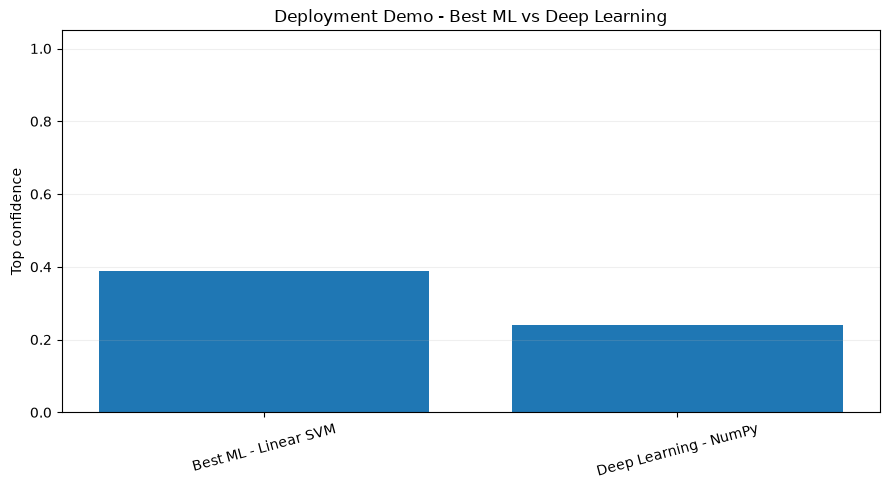

In [59]:
# Combined Web/Mobile-style result.
combined_demo = pd.DataFrame({
    "Model": [
        f"Best ML - {best_ml_deploy_name}",
        "Deep Learning - NumPy",
    ],
    "Prediction": [
        ID_TO_CLASS[ml_demo_id],
        ID_TO_CLASS[int(dl_demo_pred[0])],
    ],
    "Top Confidence": [
        float(np.max(ml_demo_prob[0])),
        float(np.max(dl_demo_prob[0])),
    ],
})

display(combined_demo)

plt.figure(figsize=(9, 5))
plt.bar(
    combined_demo["Model"],
    combined_demo["Top Confidence"],
)
plt.ylim(0, 1.05)
plt.ylabel("Top confidence")
plt.title("Deployment Demo - Best ML vs Deep Learning")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "19_deployment_two_model_confidence.png", dpi=180)
plt.show()

### Deployment Visualization Payload

A Web/Mobile result screen can be built from three reusable pieces:

```text
Prediction Card
    → predicted interest category

Probability / Confidence Chart
    → top 3–5 candidate interests

Model Comparison Panel
    → Best ML metrics vs Deep Learning metrics
```

The next cell creates the compact table that a backend can expose to the UI.

In [60]:
deployment_summary = {
    "best_ml_model": best_ml_deploy_name,
    "best_ml_prediction": ID_TO_CLASS[ml_demo_id],
    "best_ml_top5": [
        {
            "category": ID_TO_CLASS[int(i)],
            "score": float(ml_demo_prob[0, i]),
        }
        for i in ml_demo_top
    ],
    "deep_learning_prediction": ID_TO_CLASS[int(dl_demo_pred[0])],
    "deep_learning_top5": [
        {
            "category": ID_TO_CLASS[int(i)],
            "probability": float(dl_demo_prob[0, i]),
        }
        for i in dl_demo_top
    ],
}

display(pd.DataFrame([
    {
        "Model": "Best ML",
        "Prediction": deployment_summary["best_ml_prediction"],
        "Top Score": deployment_summary["best_ml_top5"][0]["score"],
    },
    {
        "Model": "Deep Learning",
        "Prediction": deployment_summary["deep_learning_prediction"],
        "Top Score": deployment_summary["deep_learning_top5"][0]["probability"],
    },
]))

,Model,Prediction,Top Score
0,Best ML,Headphones,0.389384
1,Deep Learning,Other,0.241397


# 34. Persist the Best ML Model and Deep Learning Model

The deployed application must not retrain models.

We therefore save:

### Traditional ML
- TF-IDF vectorizer
- chi-square feature selector
- best ML model
- class mapping
- rating representation

### Deep Learning
- NumPy weights
- vocabulary/tokenizer information
- architecture configuration
- class mapping

The same learned preprocessing representation must be reused during Web/Mobile inference.

In [61]:
# Save best ML bundle.
best_ml_bundle = {
    "model_name": best_ml_deploy_name,
    "model": ml_models[best_ml_deploy_name],
    "vectorizer": vectorizer,
    "selector": selector,
    "class_order": CLASS_ORDER,
    "class_to_id": CLASS_TO_ID,
    "other_label": OTHER_LABEL,
    "selected_tfidf_features": int(SELECTED_TFIDF_FEATURES),
    "top_k_categories": int(TOP_K),
    "rating_representation": "minmax 1-5 -> [0, 1]",
}

BEST_ML_BUNDLE_PATH = MODEL_DIR / "comments_best_ml_bundle.joblib"
joblib.dump(best_ml_bundle, BEST_ML_BUNDLE_PATH)

# Save Deep Learning weights and metadata.
DL_WEIGHTS_PATH = MODEL_DIR / "comments_dl_weights.npz"
np.savez(
    DL_WEIGHTS_PATH,
    embedding=dl_model.embedding,
    W1=dl_model.W1,
    b1=dl_model.b1,
    W2=dl_model.W2,
    b2=dl_model.b2,
    W3=dl_model.W3,
    b3=dl_model.b3,
)

DL_CONFIG_PATH = MODEL_DIR / "comments_dl_config.json"
dl_config = {
    "task": "ecommerce_product_interest_text_classification",
    "architecture": {
        "vocab_size": len(token_to_id),
        "embedding_dim": DL_EMBED_DIM,
        "hidden1": DL_HIDDEN_1,
        "hidden2": DL_HIDDEN_2,
        "output_dim": DL_OUTPUT_DIM,
        "max_len": MAX_LEN,
        "padding_id": PAD_ID,
        "unknown_id": UNK_ID,
    },
    "learning_rate": DL_LEARNING_RATE,
    "epochs": DL_EPOCHS,
    "batch_size": DL_BATCH_SIZE,
    "deep_learning_framework": "None - NumPy only",
    "class_order": CLASS_ORDER,
}

DL_VOCAB_PATH = MODEL_DIR / "comments_dl_vocab.json"
json.dump(
    {
        "token_to_id": token_to_id,
        "id_to_token": id_to_token,
    },
    open(DL_VOCAB_PATH, "w", encoding="utf-8"),
    ensure_ascii=False,
    indent=2,
)

json.dump(
    dl_config,
    open(DL_CONFIG_PATH, "w", encoding="utf-8"),
    ensure_ascii=False,
    indent=2,
)

print("Saved:")
print(BEST_ML_BUNDLE_PATH)
print(DL_WEIGHTS_PATH)
print(DL_VOCAB_PATH)
print(DL_CONFIG_PATH)

Saved:
C:\Users\ADMIN\Downloads\Intelligent System\asssignment 3\DATA\comments\model_comments\comments_best_ml_bundle.joblib
C:\Users\ADMIN\Downloads\Intelligent System\asssignment 3\DATA\comments\model_comments\comments_dl_weights.npz
C:\Users\ADMIN\Downloads\Intelligent System\asssignment 3\DATA\comments\model_comments\comments_dl_vocab.json
C:\Users\ADMIN\Downloads\Intelligent System\asssignment 3\DATA\comments\model_comments\comments_dl_config.json


# 35. Save Final Comparison and Deployment Metadata

The following artifacts support the report and the Web/Mobile application.

```text
model_comments/
├── comments_best_ml_bundle.joblib
├── comments_dl_weights.npz
├── comments_dl_vocab.json
├── comments_dl_config.json
├── comments_four_model_comparison.csv
├── comments_deployment_metrics.json
└── figures/
```

In [62]:
comparison_path = MODEL_DIR / "comments_four_model_comparison.csv"
final_four_ranked.to_csv(comparison_path, index=False)

deployment_metrics = {
    "task": "multi_class_ecommerce_product_interest_text_classification",
    "classes": CLASS_ORDER,
    "best_ml_model": best_ml_deploy_name,
    "best_ml_metrics": {
        k: (None if pd.isna(v) else float(v))
        for k, v in final_four.set_index("Model").loc[
            best_ml_deploy_name
        ].to_dict().items()
        if k != "Training_Time_sec"
    },
    "deep_learning_metrics": {
        k: (
            None if pd.isna(v)
            else float(v)
        )
        for k, v in final_four.set_index("Model").loc[
            "Deep Learning - NumPy"
        ].to_dict().items()
        if k != "Training_Time_sec"
    },
    "framework": "Traditional ML: scikit-learn; Deep Learning: NumPy only",
    "split": "70% train / 15% validation / 15% test",
    "random_seed": SEED,
}

deployment_metrics_path = MODEL_DIR / "comments_deployment_metrics.json"
json.dump(
    deployment_metrics,
    open(deployment_metrics_path, "w", encoding="utf-8"),
    ensure_ascii=False,
    indent=2,
)

print("Comparison CSV:", comparison_path)
print("Deployment JSON:", deployment_metrics_path)

Comparison CSV: C:\Users\ADMIN\Downloads\Intelligent System\asssignment 3\DATA\comments\model_comments\comments_four_model_comparison.csv
Deployment JSON: C:\Users\ADMIN\Downloads\Intelligent System\asssignment 3\DATA\comments\model_comments\comments_deployment_metrics.json


# 36. Reproducibility Check

A second user should be able to reproduce the core experiment from the documented settings.

Important reproducibility information:

- random seed = 42
- split = 70/15/15, stratified
- target = top 15 raw categories + `Other`
- TF-IDF word/bigram representation
- chi-square selection = up to 20,000 text features
- rating appended as a compact auxiliary signal
- NumPy vocabulary learned from training reviews only
- maximum DL sequence length = 60
- embedding dimension = 24
- hidden layers = 64 → 32
- output = number of interest classes
- Deep Learning optimizer = manual gradient descent
- no TensorFlow / PyTorch / Keras

In [63]:
reproducibility = {
    "random_seed": SEED,
    "split": "70% train / 15% validation / 15% test",
    "stratified": True,
    "target": "top 15 raw categories + Other",
    "raw_rows": int(len(df_raw)),
    "clean_rows": int(len(df)),
    "raw_categories": int(df["category"].nunique()),
    "modeling_classes": CLASS_ORDER,
    "tfidf_ngram_range": [1, 2],
    "tfidf_min_df": TFIDF_MIN_DF,
    "tfidf_max_df": TFIDF_MAX_DF,
    "tfidf_max_features": TFIDF_MAX_FEATURES,
    "selected_text_features": int(SELECTED_TFIDF_FEATURES),
    "dl_vocab_size": int(len(token_to_id)),
    "dl_max_len": MAX_LEN,
    "dl_embedding_dim": DL_EMBED_DIM,
    "dl_hidden1": DL_HIDDEN_1,
    "dl_hidden2": DL_HIDDEN_2,
    "dl_learning_rate": DL_LEARNING_RATE,
    "dl_epochs": DL_EPOCHS,
    "dl_batch_size": DL_BATCH_SIZE,
    "deep_learning_framework": "None - NumPy only",
    "best_ml_model": best_ml_deploy_name,
}

repro_path = MODEL_DIR / "comments_reproducibility.json"
json.dump(reproducibility, open(repro_path, "w", encoding="utf-8"), indent=2)

display(pd.DataFrame(
    list(reproducibility.items()),
    columns=["Parameter", "Value"],
))

,Parameter,Value
0,random_seed,42
1,split,70% train / 15% validation / 15% test
2,stratified,True
3,target,top 15 raw categories + Other
4,raw_rows,44756
5,clean_rows,44756
6,raw_categories,162
7,modeling_classes,"[Cell Phones & Smartphones, Digital Cameras, V..."
8,tfidf_ngram_range,"[1, 2]"
9,tfidf_min_df,2


# 37. Final Conclusion

The final conclusion should be written from the executed results rather than from a fixed
template.

The experiment demonstrates the complete Assignment 02 principle:

```text
Raw e-commerce reviews
→ Clean
→ Text representation
→ Feature engineering / feature selection
→ 3 traditional ML models
→ Deep Learning representation learning
→ Fair four-model evaluation
→ Persist
→ Deploy
```

### Main lessons

1. Text data cannot be given directly to a mathematical model; it must first be represented.
2. Feature engineering remains critical even when the raw dataset has only a few columns.
3. For ML, TF-IDF plus feature selection creates a controlled sparse numerical representation.
4. For Deep Learning, token IDs are mapped to learned embeddings and transformed by nonlinear
   layers.
5. Backpropagation remains the chain-rule mechanism described in the Deep Learning lecture.
6. The final comparison must include all four models together on one untouched test set.
7. A deployable intelligent system includes preprocessing, saved models, inference logic,
   and user-facing prediction results—not only a training script.

## Final system summary

```text
User
 ↓
Review title + review content + rating
 ↓
Validation
 ↓
Saved preprocessing
 ├── Best ML: TF-IDF → feature selection → classifier
 └── Deep Learning: tokenizer → token IDs → embedding → NumPy MLP
 ↓
Prediction
 ↓
Interest category + confidence/probabilities
 ↓
Web / Mobile UI
```

The notebook therefore covers the complete path from **Data → Representation → Learning →
Evaluation → Deployment**, with the Deep Learning implementation shown explicitly step by step.